# Logistic Regression (Breast Cancer Malignant/Benign Prediction)



## Penjelasan Kolom:

### 
- id = Nomor identifikasi unik untuk setiap sampel pasien
- diagnosis = Jenis diagnosis kanker (Malignant & Benign)
- radius_mean =Rata-rata jarak dari pusat ke batas luar sel (ukuran radius)
- texture_mean = Variasi skala intensitas tekstur pada sel
- perimeter_mean = Rata-rata keliling sel
- area_mean = Rata-rata luas permukaan sel
- smoothness_mean = Rata-rata variasi panjang tepi sel
- compactness_mean = Rata-rata hubungan antara keliling dan luas sel
- concavity_mean = Tingkat cekungan pada bagian kontur sel
- concave points_mean = Jumlah titik cekungan pada kontur sel
- symmetry_mean = Rata-rata tingkat simetri sel
- fractal_dimension_mean = Kompleksitas perbatasan kontur sel
- radius_se = Standar deviasi ukuran radius
- texture_se = Standar deviasi variasi tekstur
- perimeter_se = Standar deviasi keliling sel
- area_se = Standar deviasi luas permukaan sel
- smoothness_se = Standar deviasi variasi panjang tepi
- compactness_se = Standar deviasi antara keliling dan luas sel
- concavity_se = Standar deviasi tingkat cekungan kontur sel
- concave points_se = Standar deviasi jumlah titik cekungan sel
- symmetry_se = Standar deviasi tingkat simetri sel
- fractal_dimension_se = Standar deviasi kompleksitas perbatasan kontur sel
- radius_worst = Nilai maksimum ukuran radius
- texture_worst = Nilai maksimum variasi tekstur
- perimeter_worst = Nilai maksimum keliling sel
- area_worst = Nilai maksimum luas permukaan sel
- smoothness_worst = Nilai maksimum variasi panjang tepi sel
- compactness_worst = Nilai maksimum hubungan antara keliling dan luas
- concavity_worst = Nilai maksimum tingkat cekungan kontur sel
- concave points_worst = Nilai maksimum jumlah titik cekungan sel
- symmetry_worst = Nilai maksimum tingkat simetri sel
- fractal_dimension_worst = Nilai maksimum kompleksitas perbatasan kontur sel

## A. Data Preparation

### A.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')
sns.set(style='darkgrid', font_scale=1.1)

### A.2 Load Data

In [2]:
try:
    df = pd.read_csv('breast-cancer.csv')
    print("Berhasil membaca csv")
except Exception as e:
    print("Gagal membaca data")

Berhasil membaca csv


### A.3 Melihat 5 Data Teratas dan 5 Data Terbawah

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


### A.4 Melihat Informasi Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

### A.5 Melihat Dimensi Data

In [6]:
df.shape

(569, 32)

### A.6 Cek Data Duplikat

In [7]:
df.duplicated().sum()

np.int64(0)

### A.7 Cek Data Hilang

In [8]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

## B. Data Preprocessing

### B.1 Encoding/Mapping

In [9]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [10]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [11]:
diagnosis_mapping = {'M' : 1, 'B' : 0}
df['diagnosis'] = df['diagnosis'].map(diagnosis_mapping)

### B.2 Cek Outliers

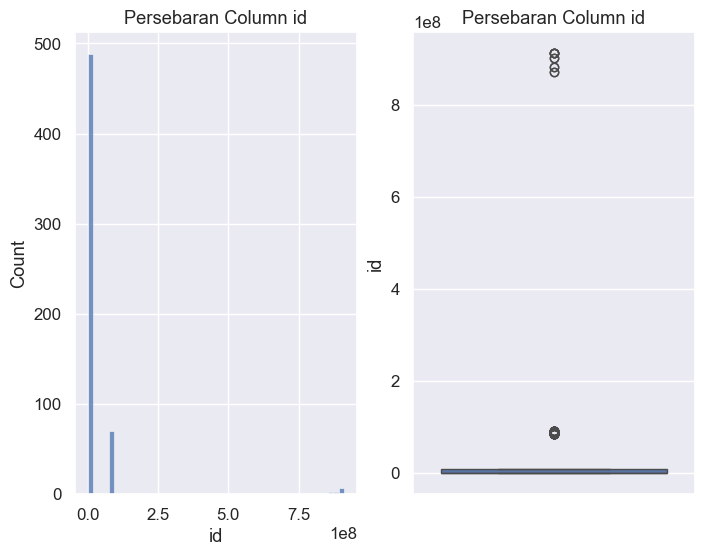

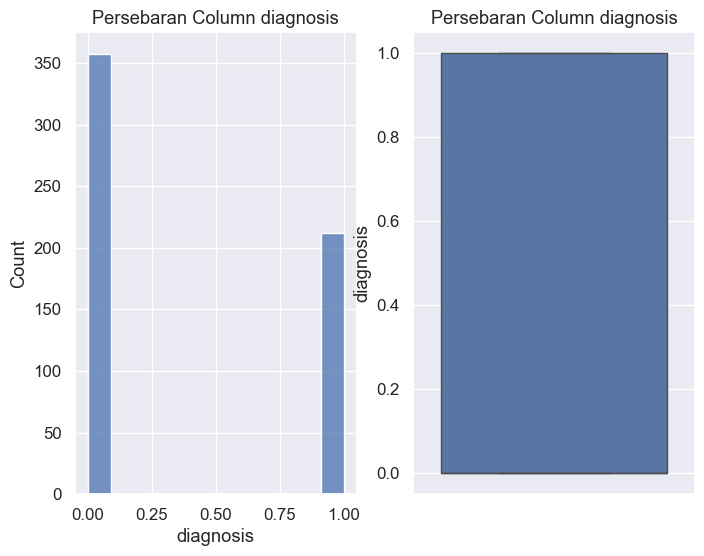

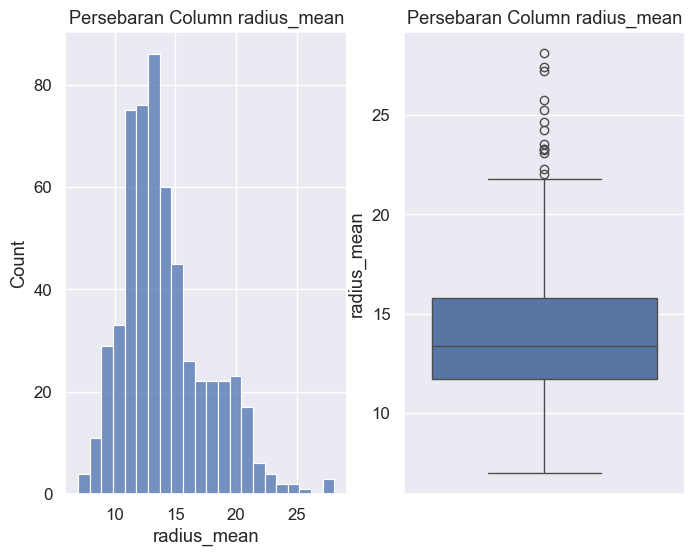

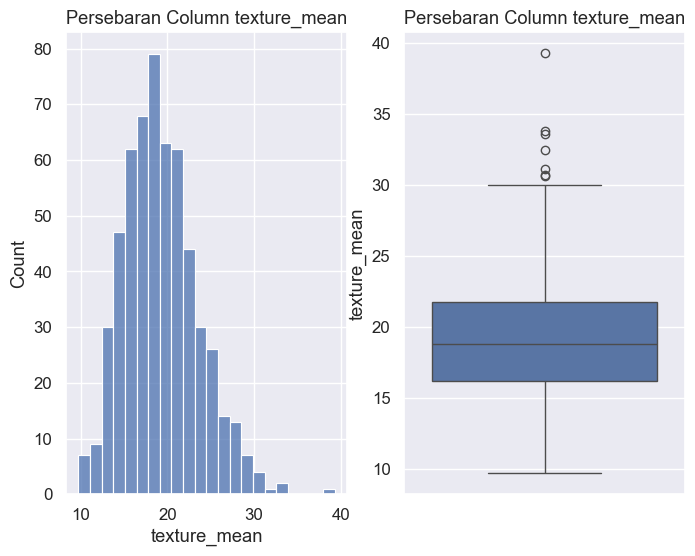

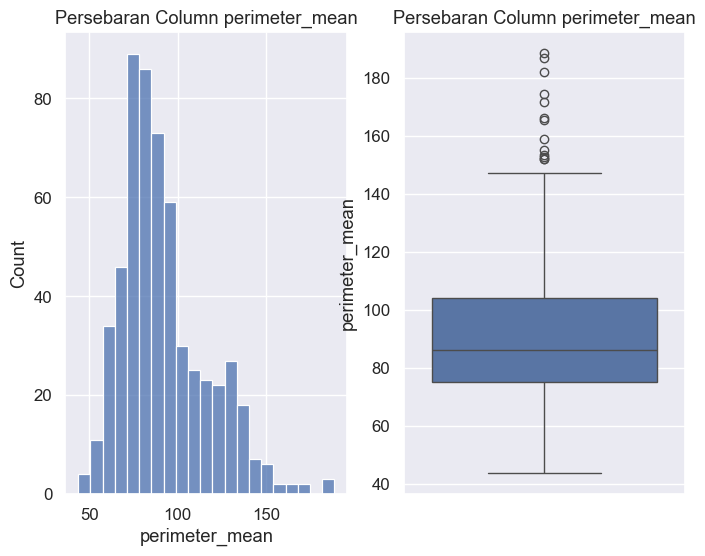

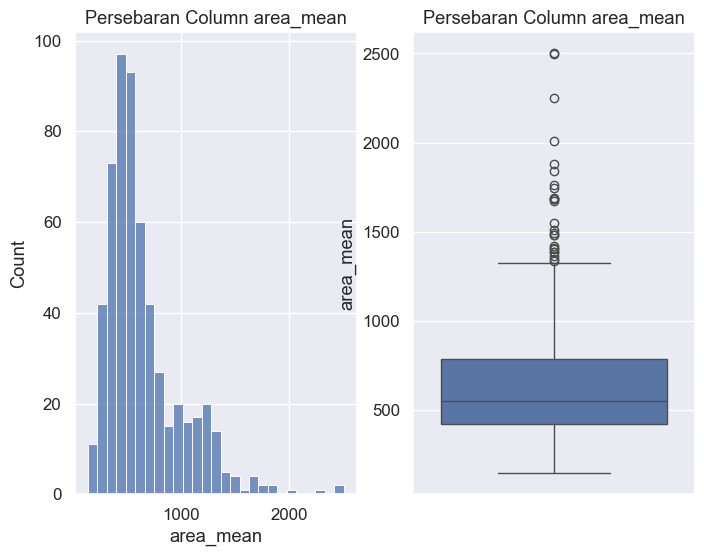

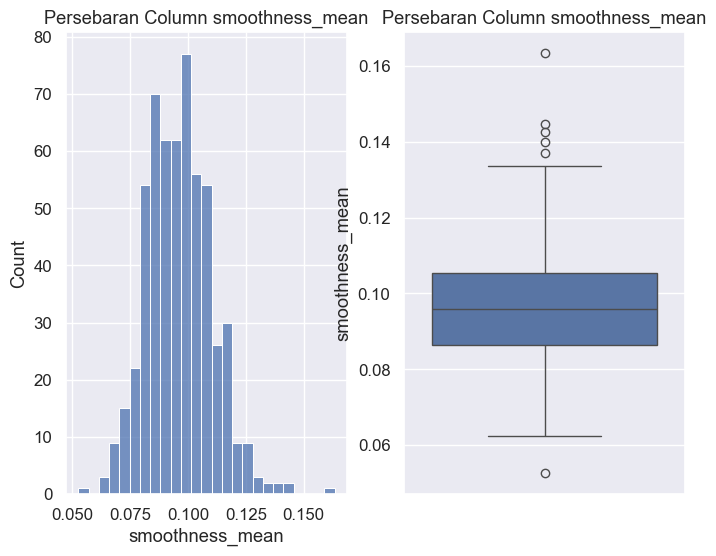

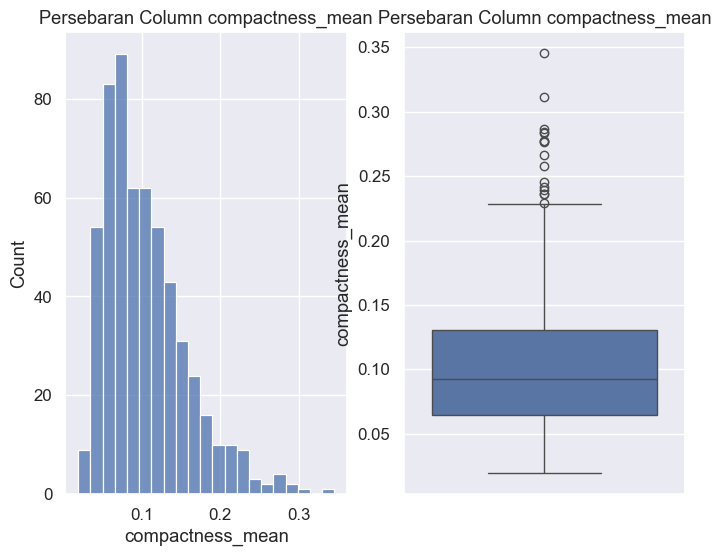

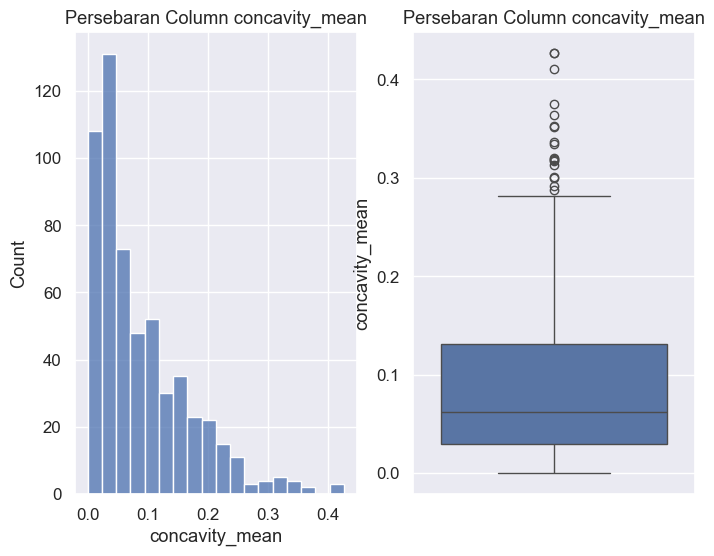

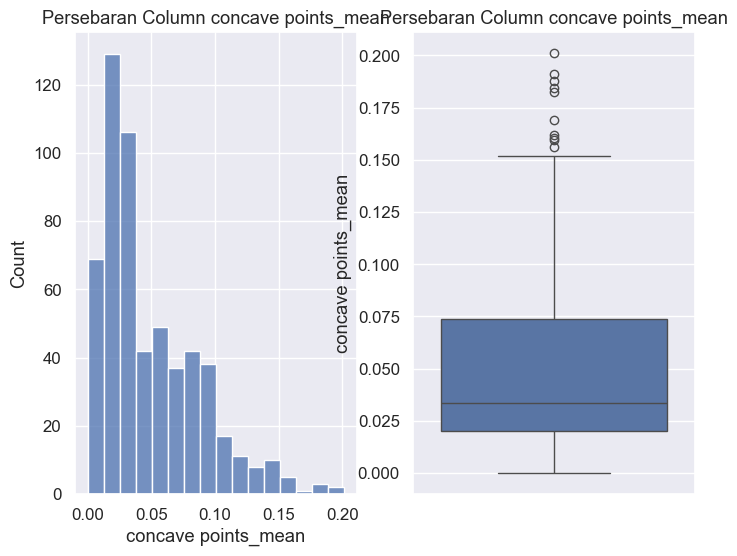

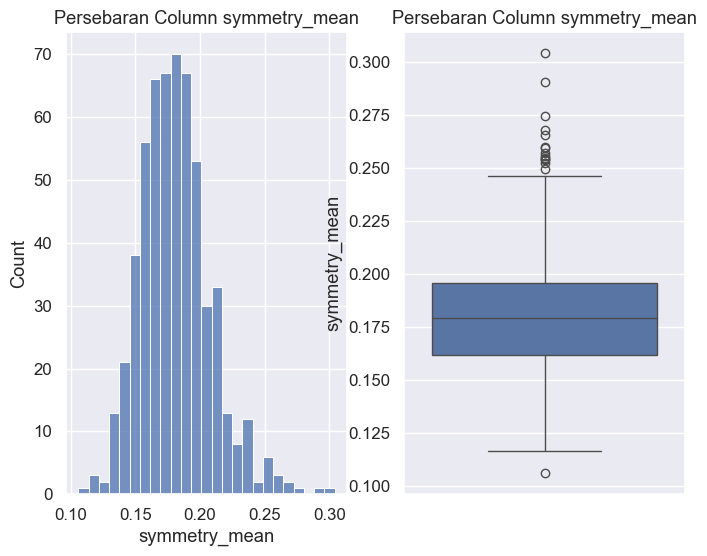

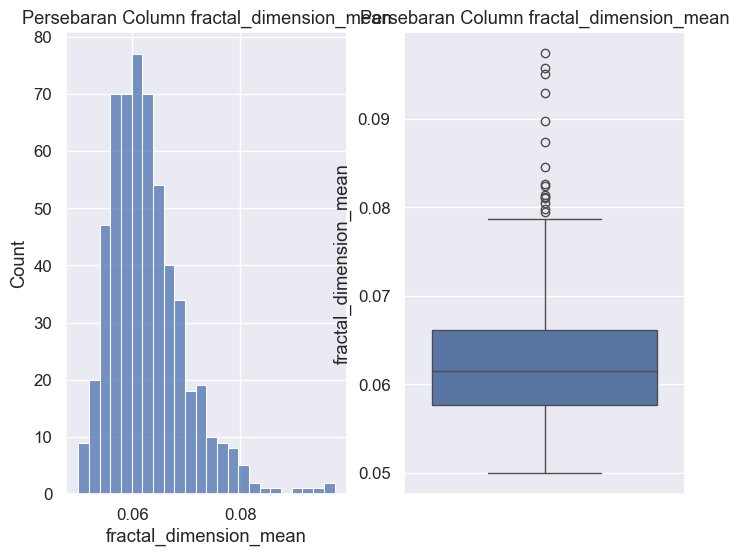

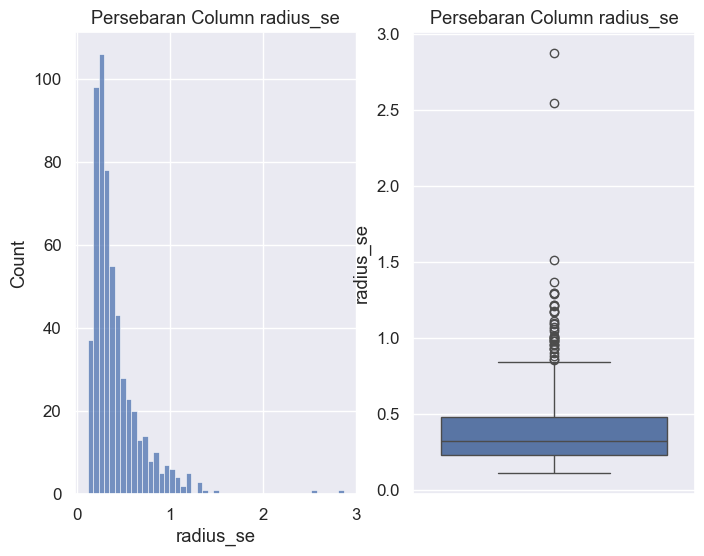

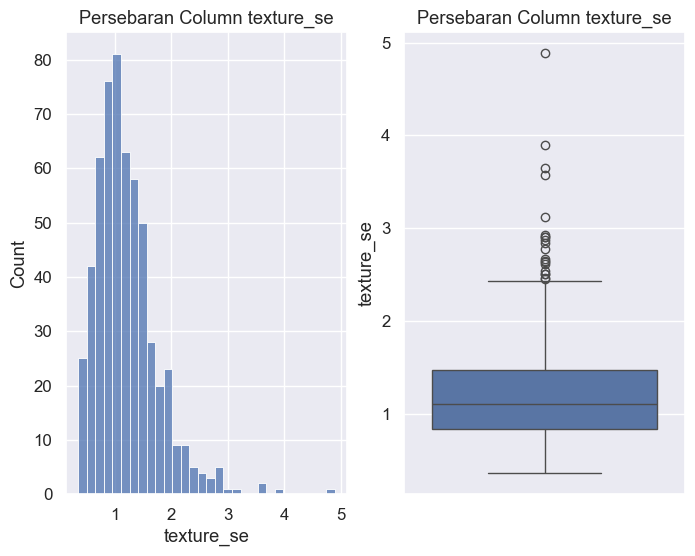

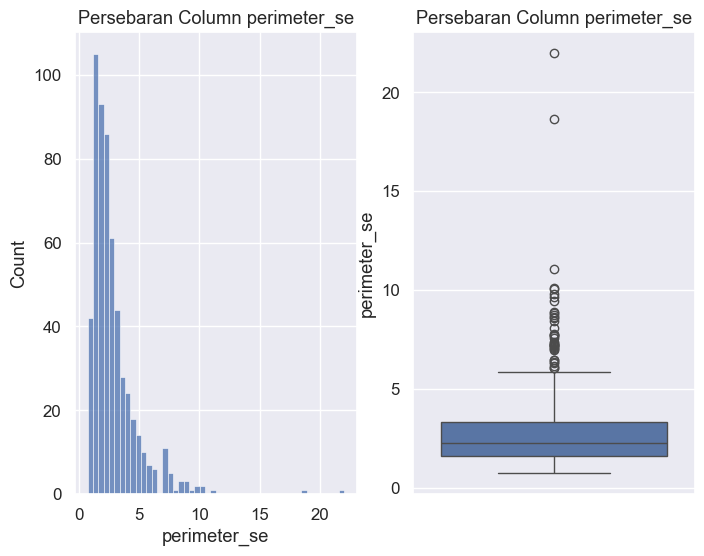

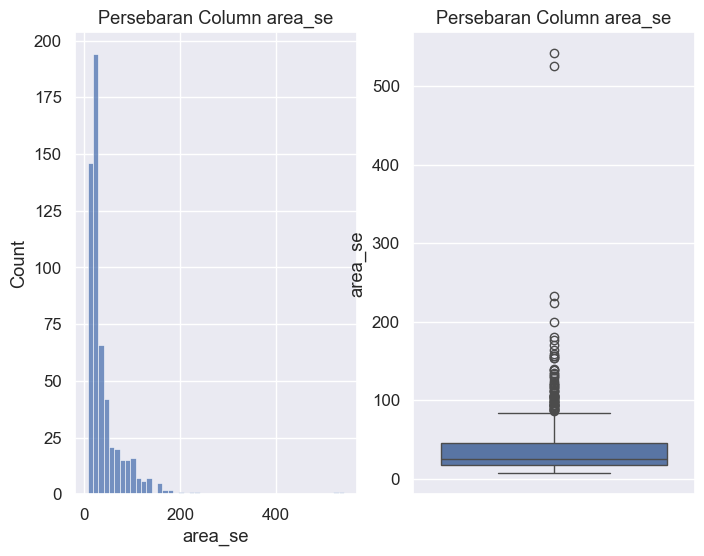

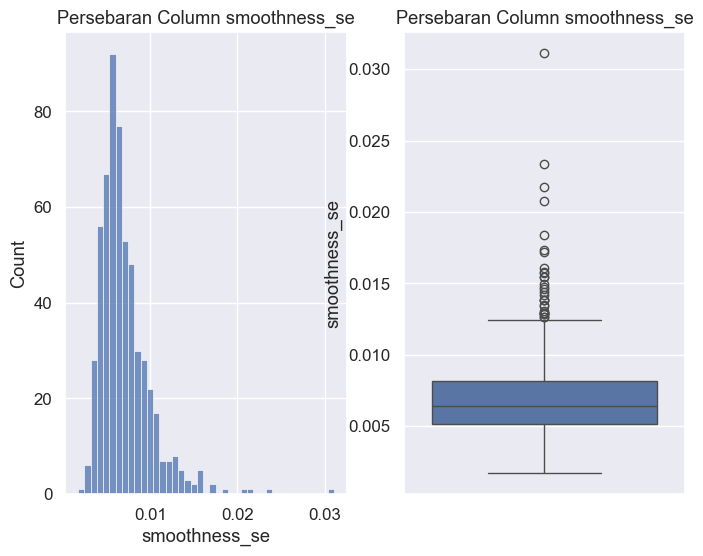

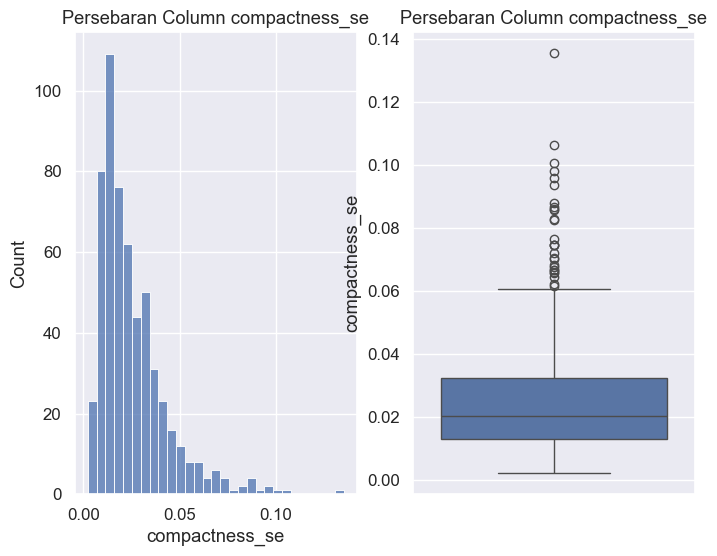

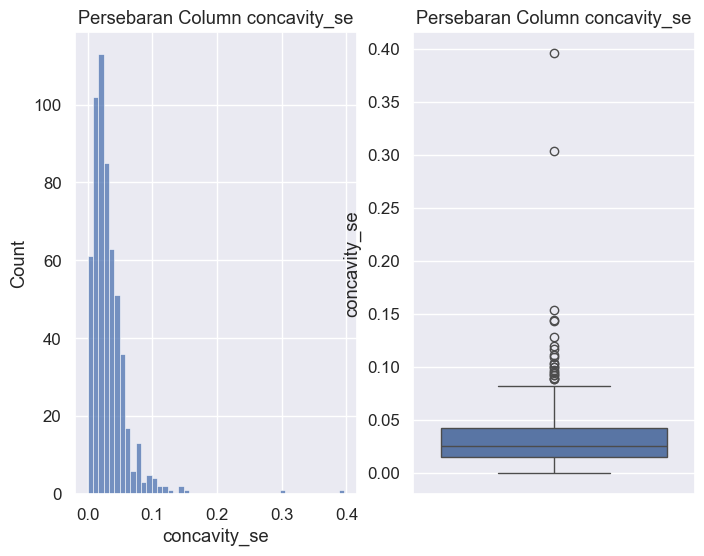

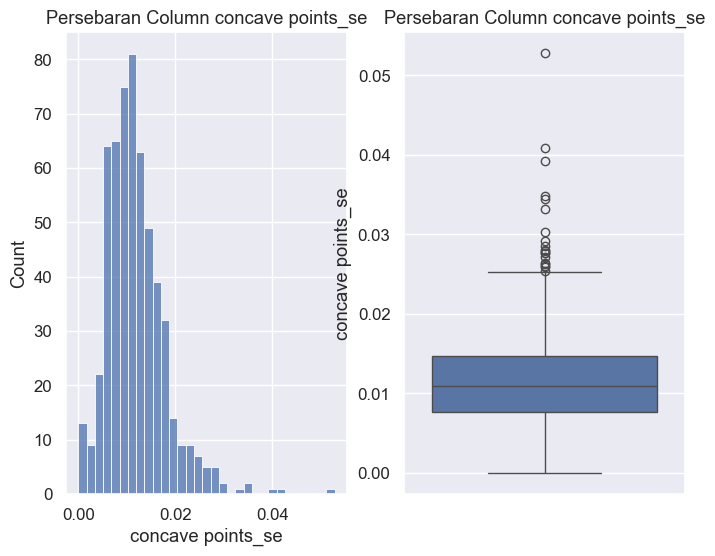

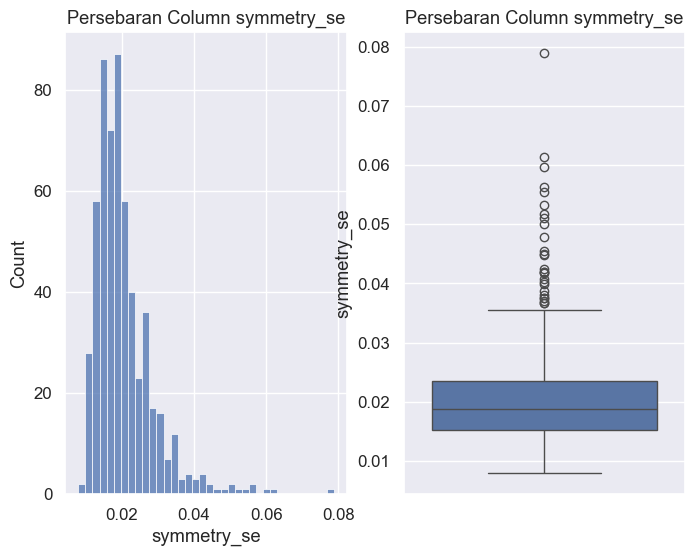

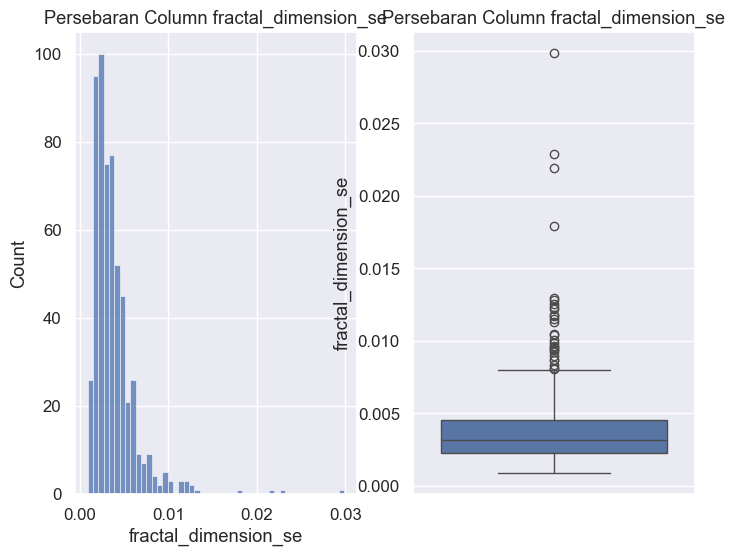

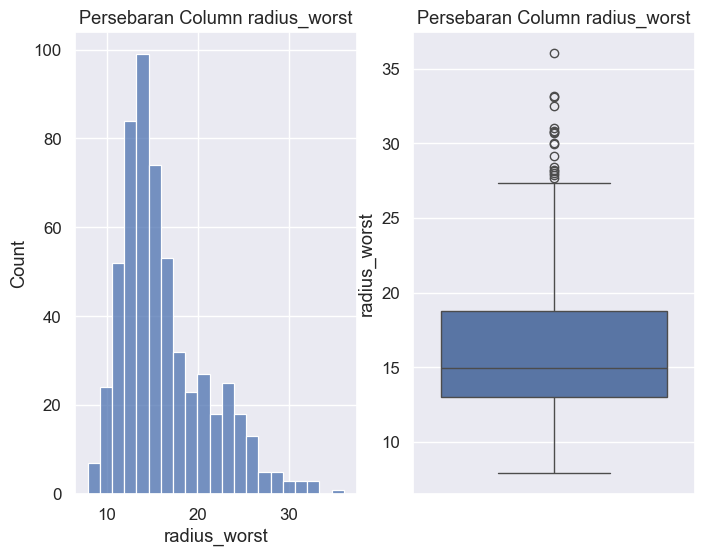

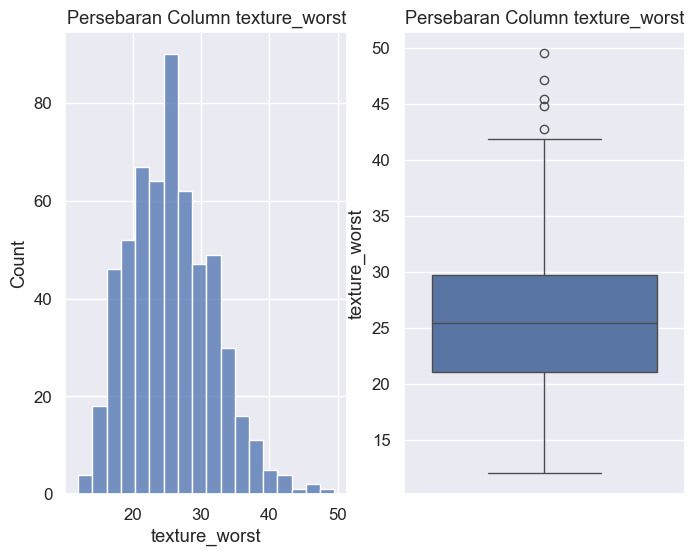

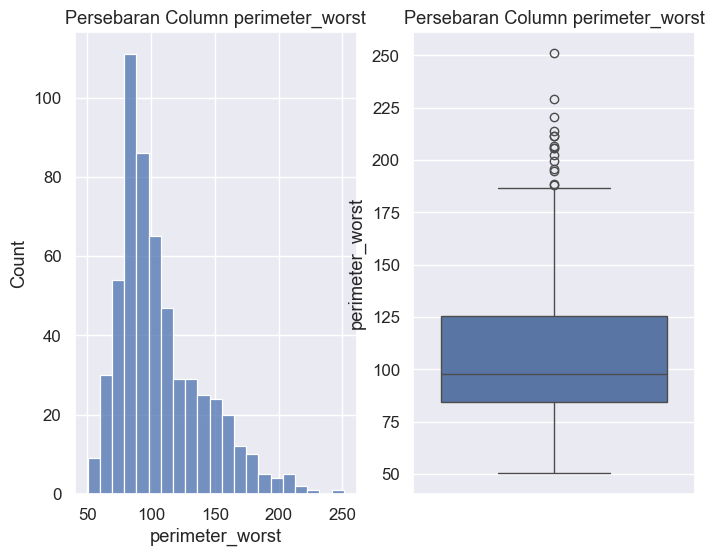

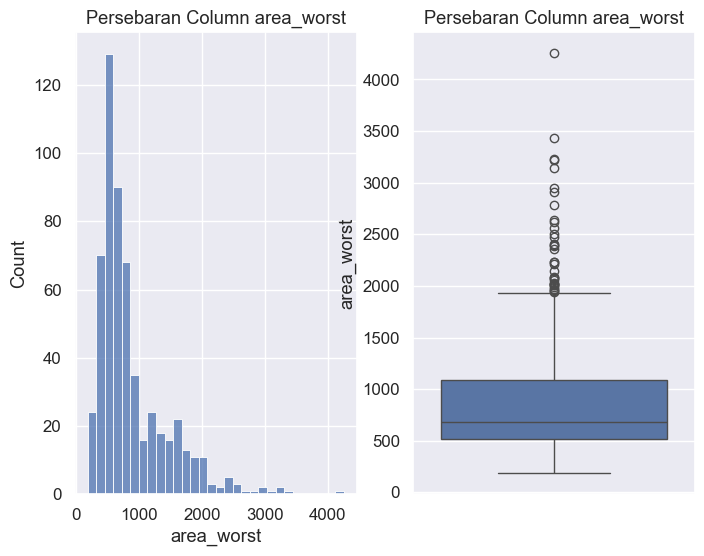

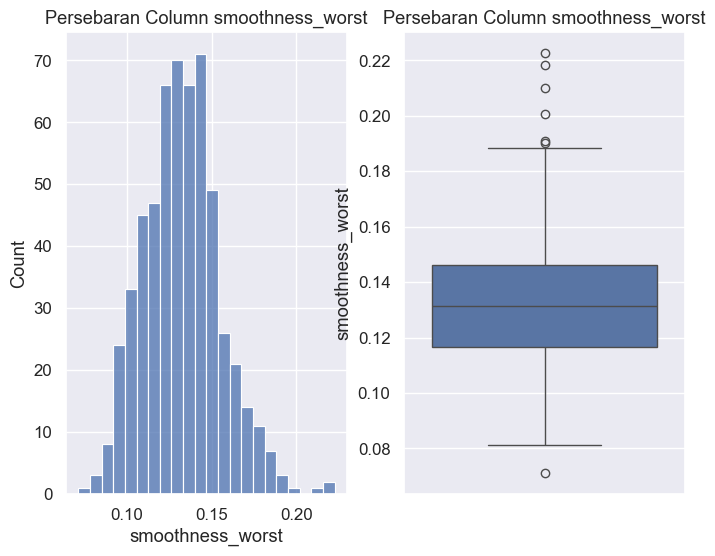

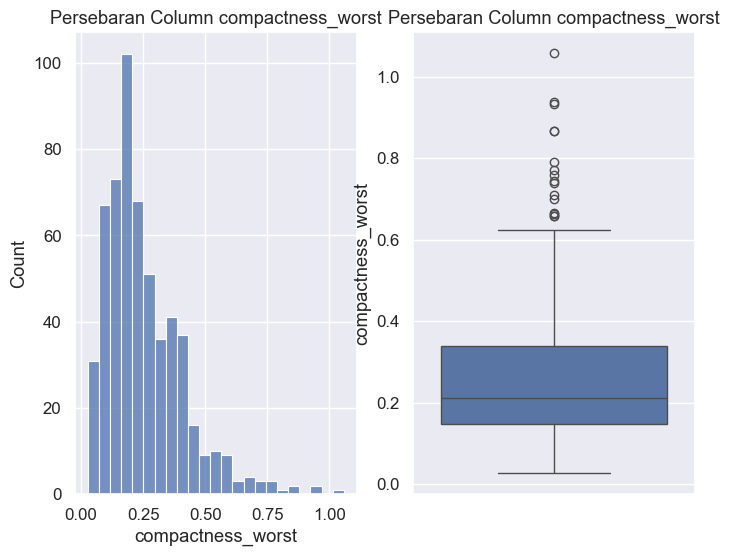

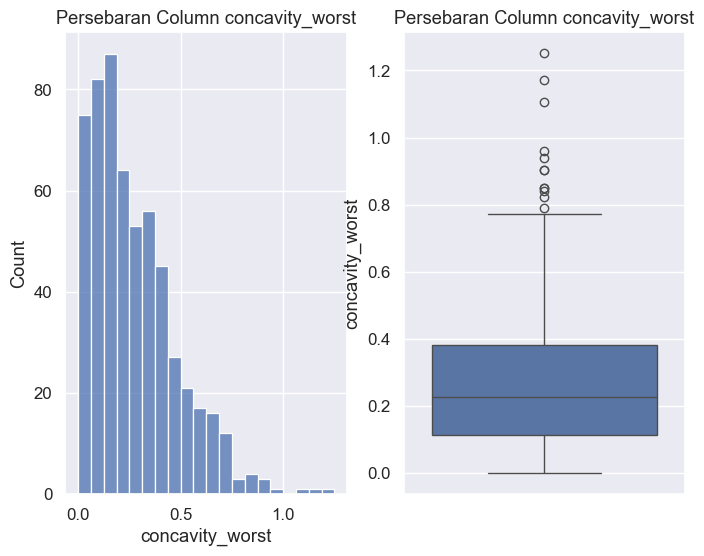

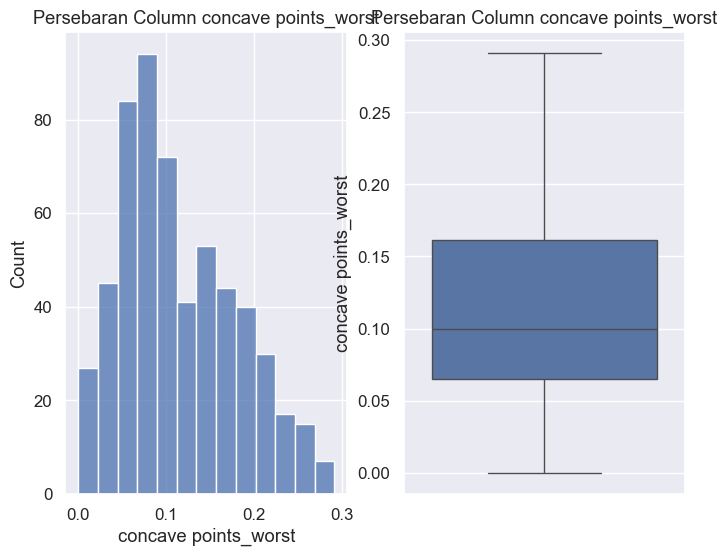

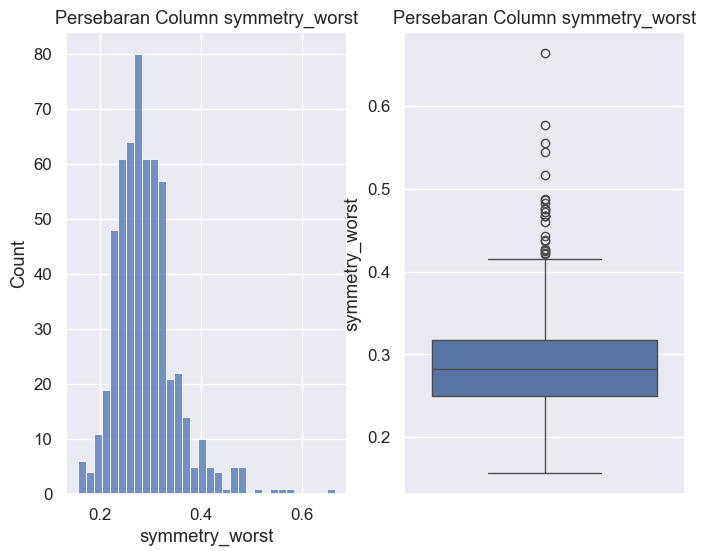

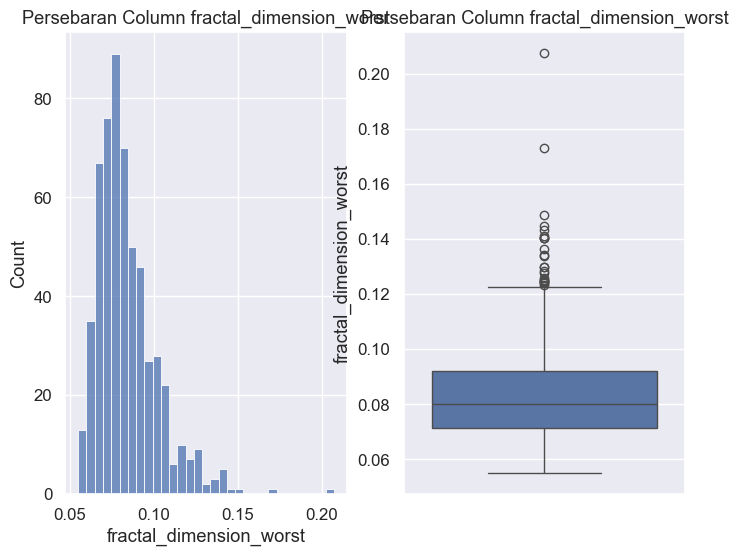

In [12]:
for col in df.select_dtypes(include='number'):
    fig, axes = plt.subplots(1, 2, figsize=(8,6))
    sns.histplot(df[col], ax=axes[0])
    axes[0].set_title(f"Persebaran Column {col}")
    sns.boxplot(df[col], ax=axes[1])
    axes[1].set_title(f"Persebaran Column {col}")
    
    plt.show()

### B.3 Handling Outliers

In [13]:
for col in df.columns:
    Q3 = df[col].quantile(0.75)
    Q1 = df[col].quantile(0.25)
    IQR = Q3 - Q1
    
    lowbound = Q1 - 1.5 * IQR
    upbound = Q3 + 2.5 * IQR
    
    df.loc[(df[col] < lowbound) | (df[col] > upbound), col] = df[col].median()

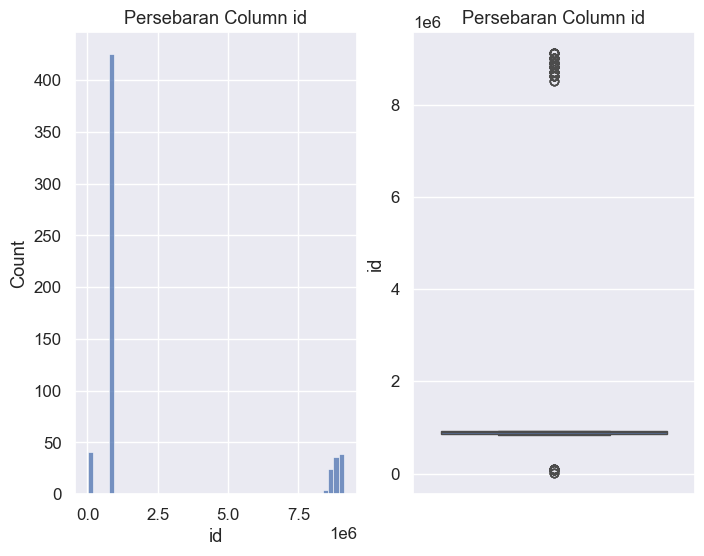

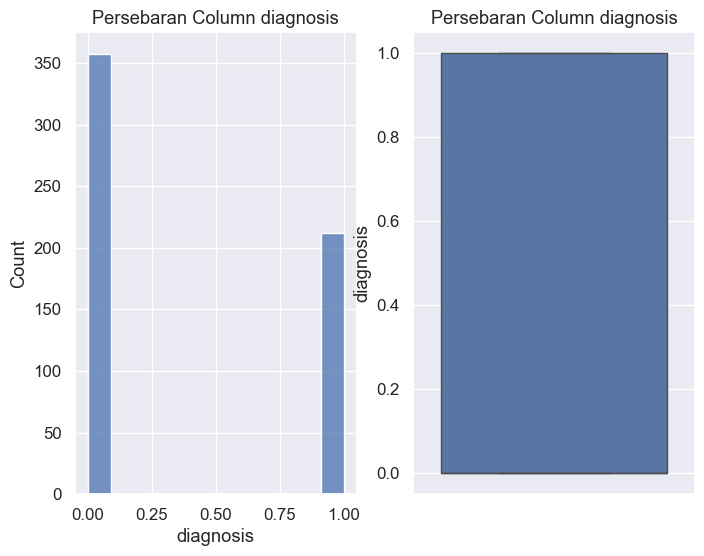

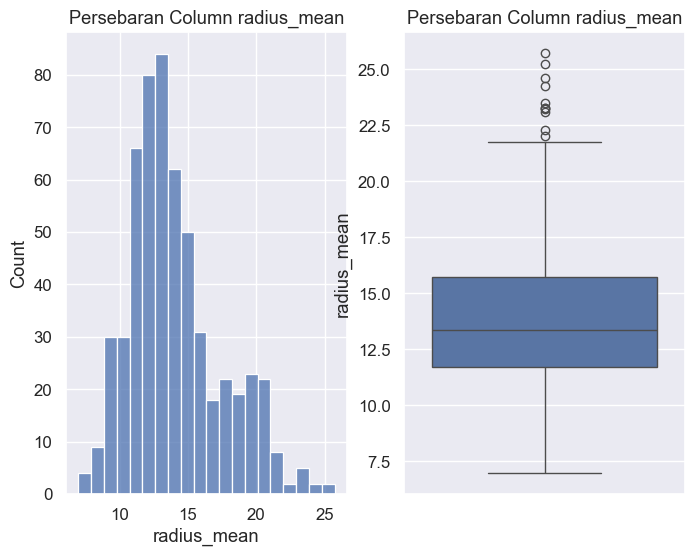

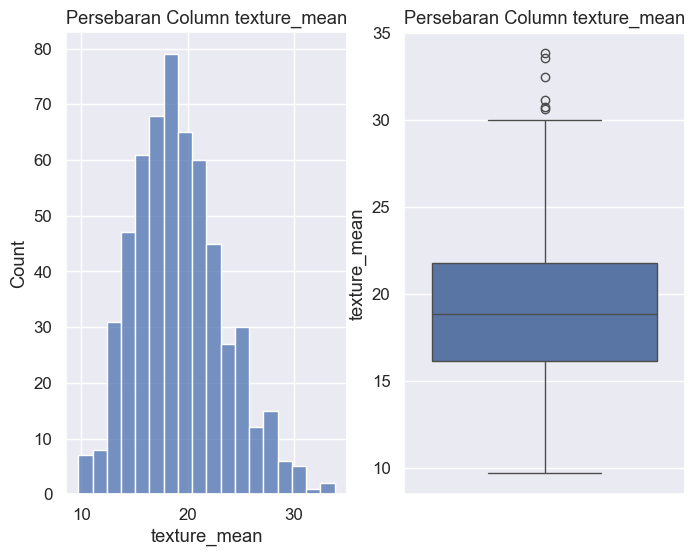

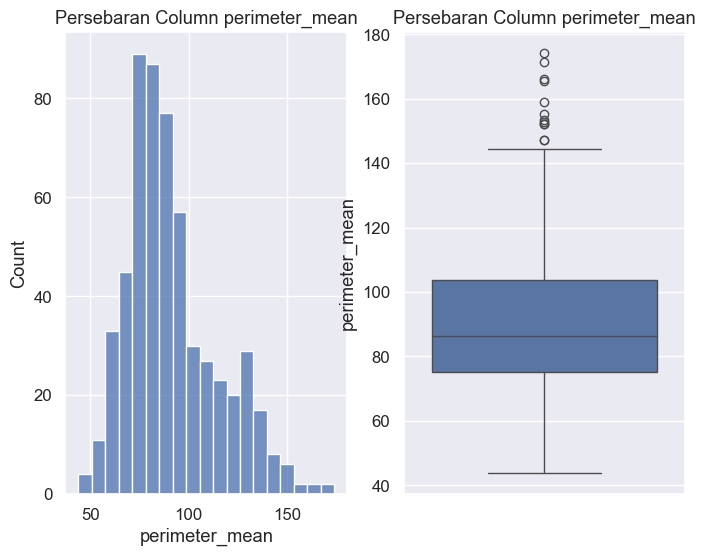

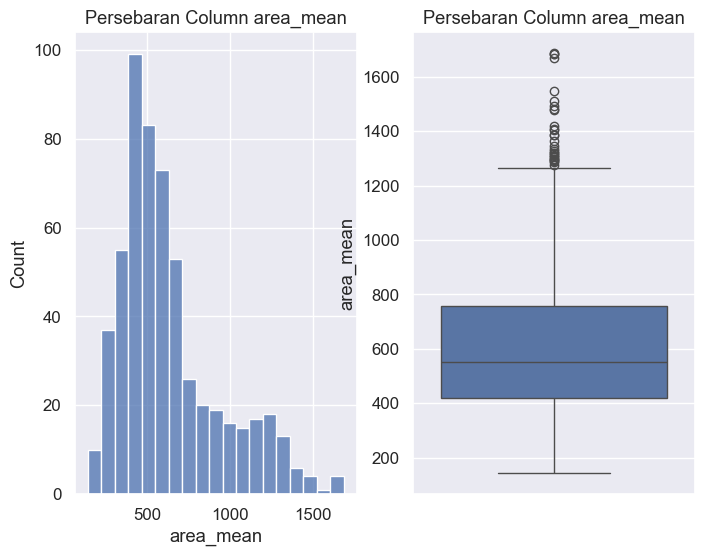

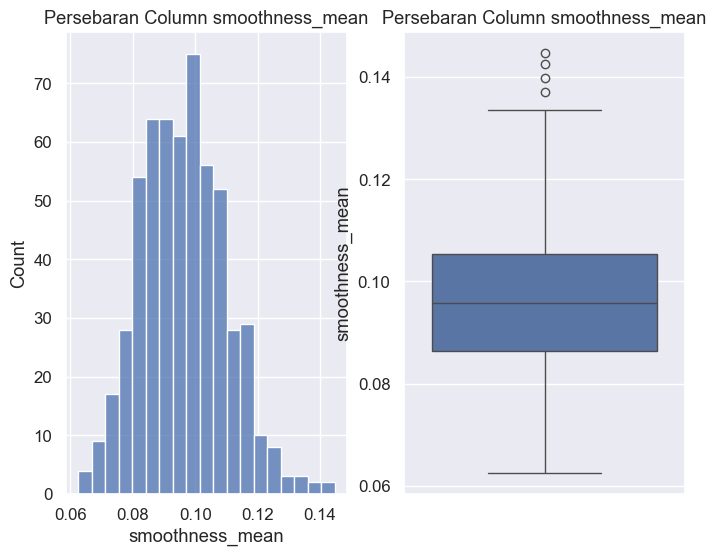

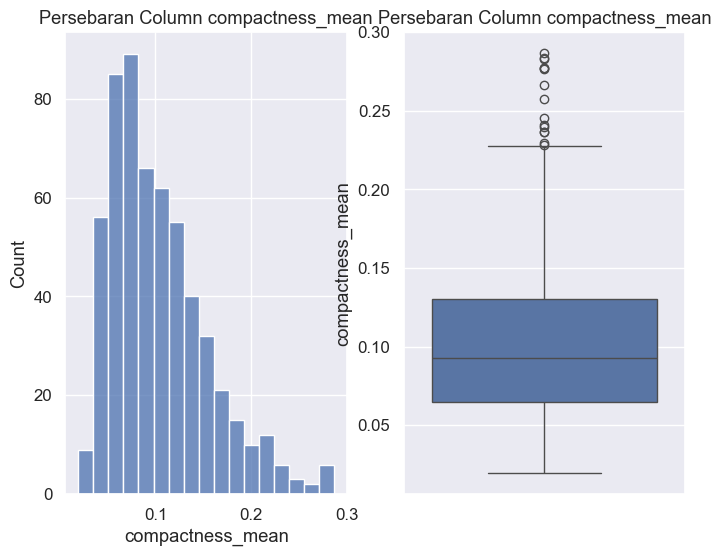

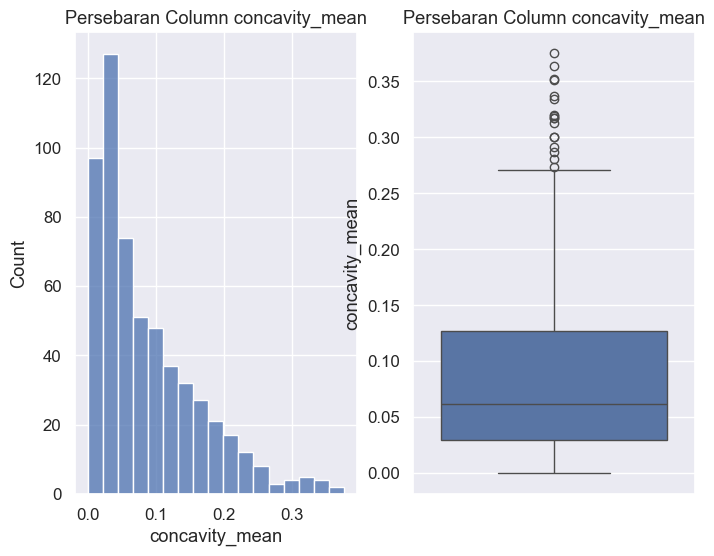

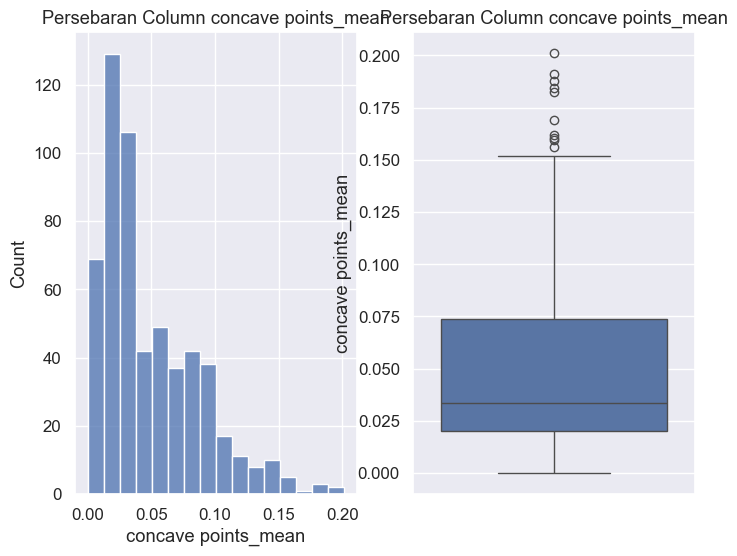

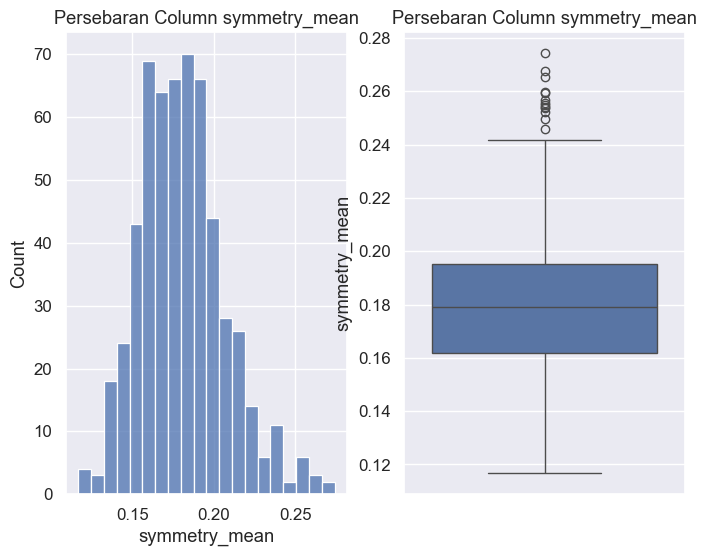

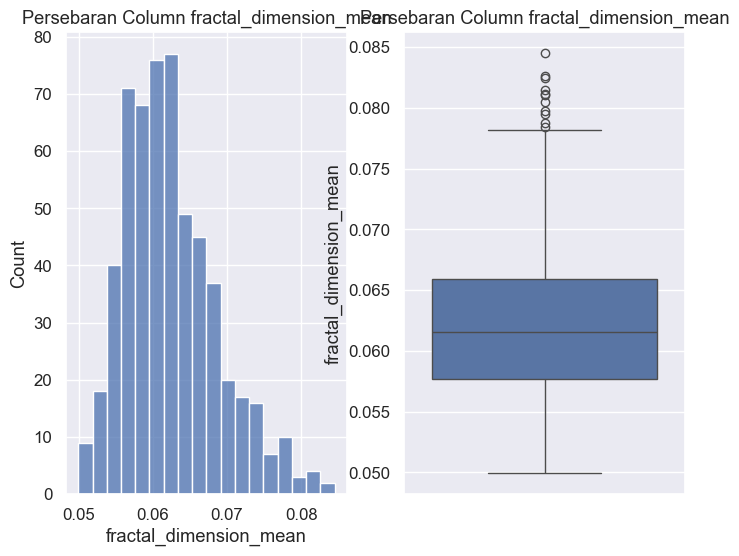

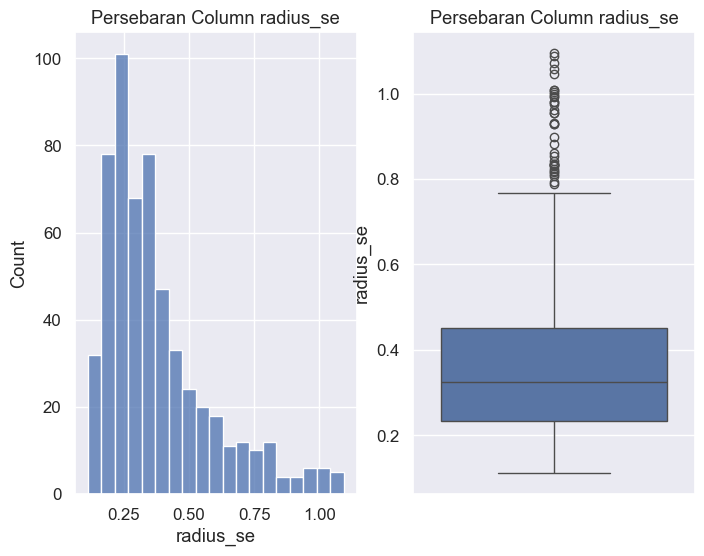

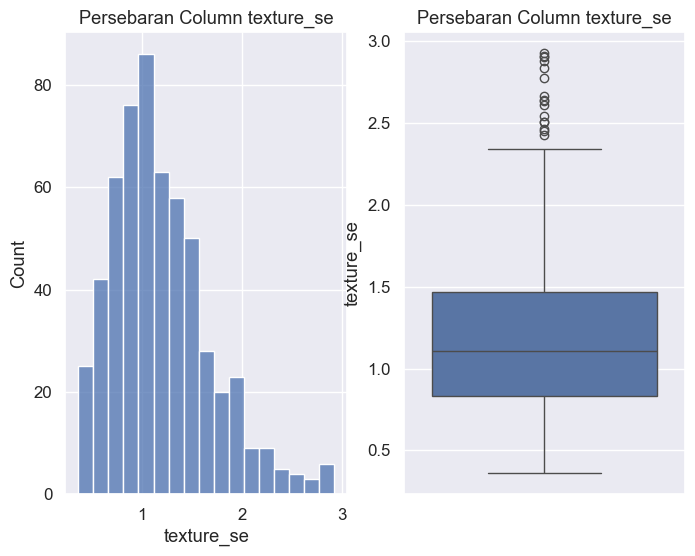

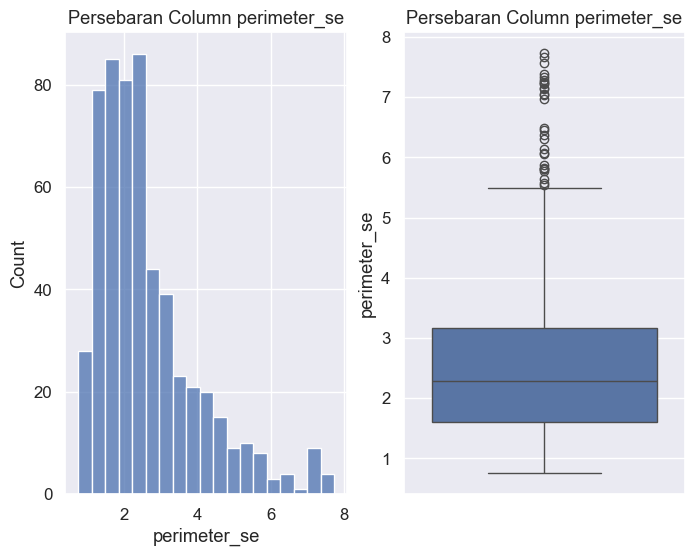

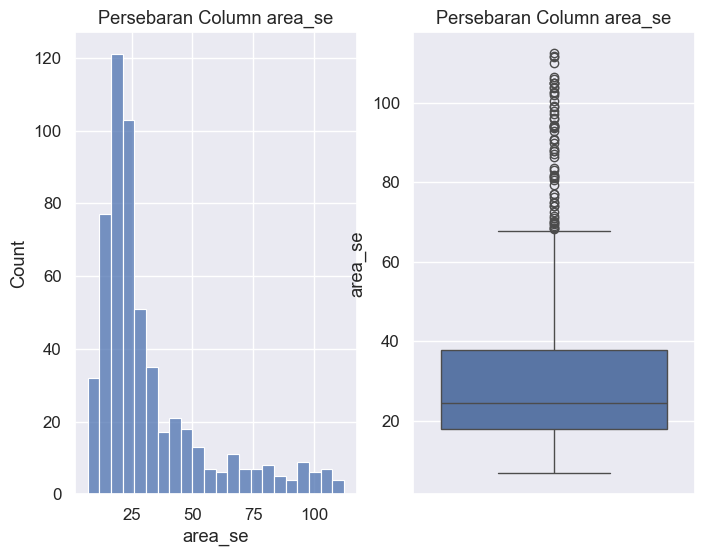

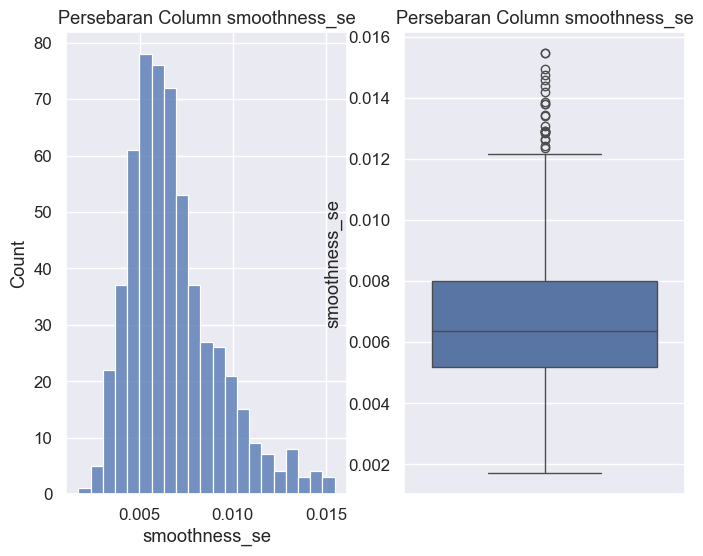

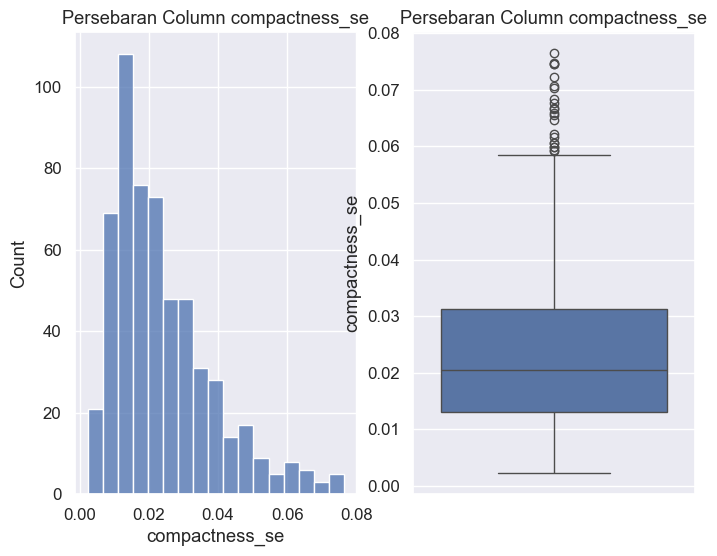

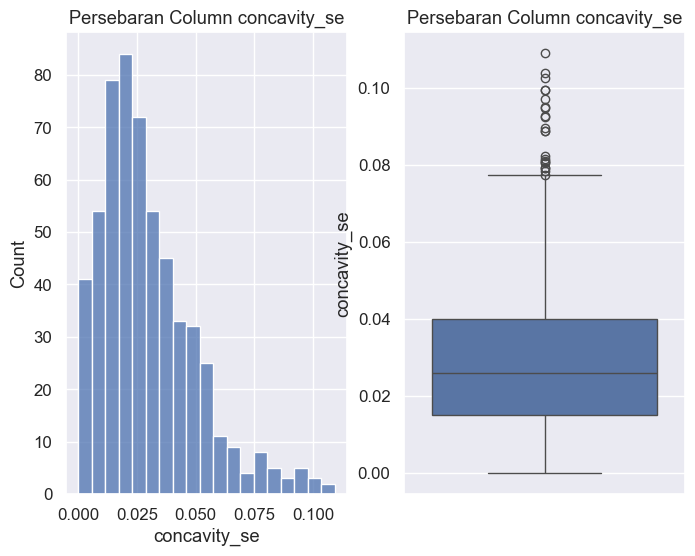

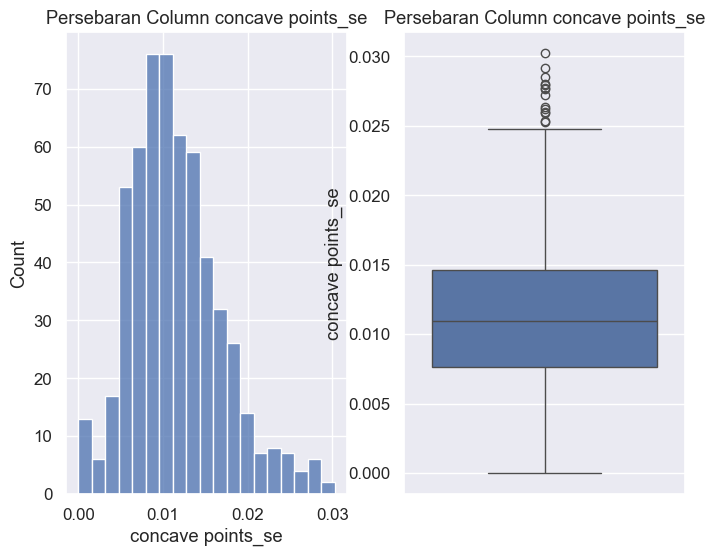

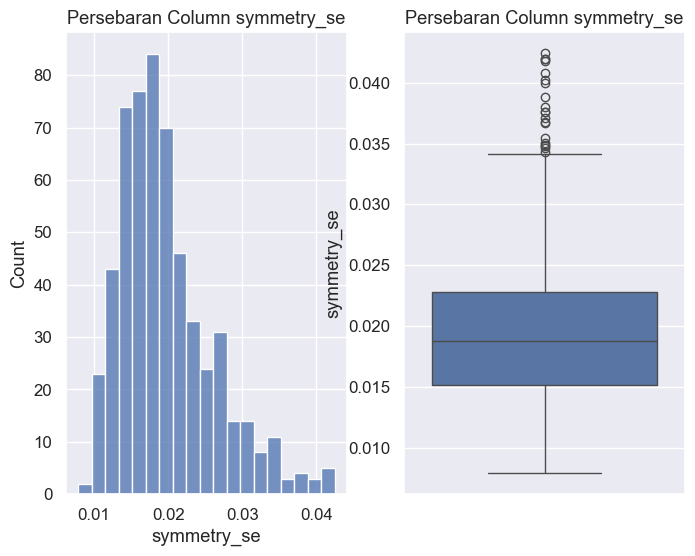

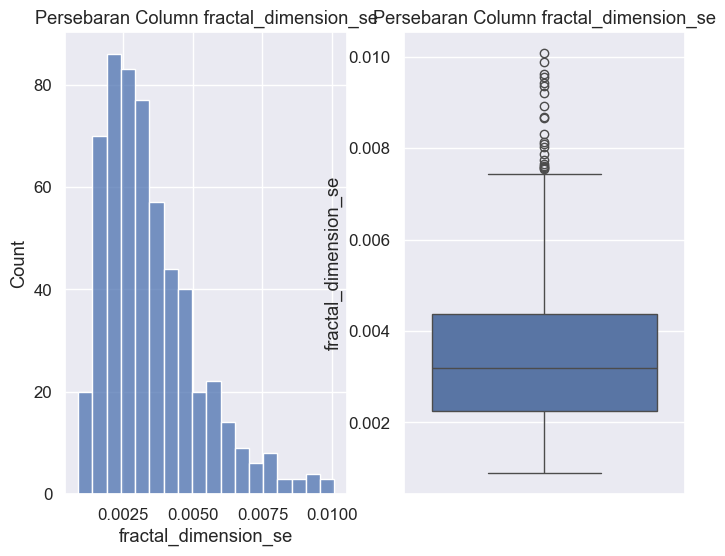

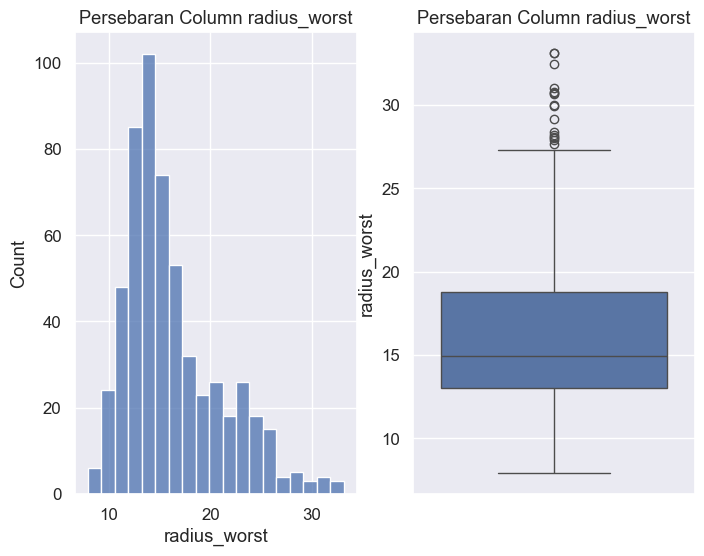

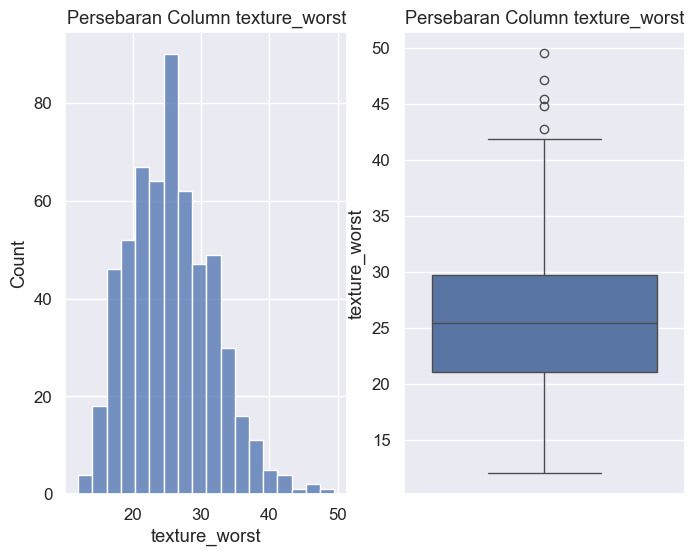

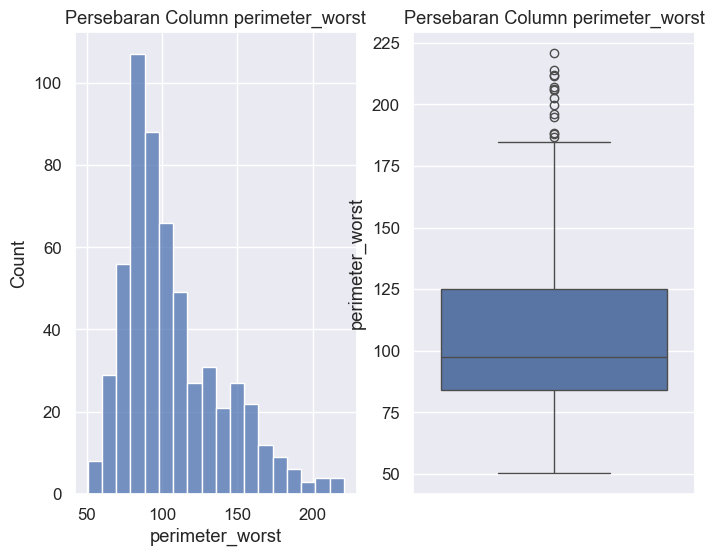

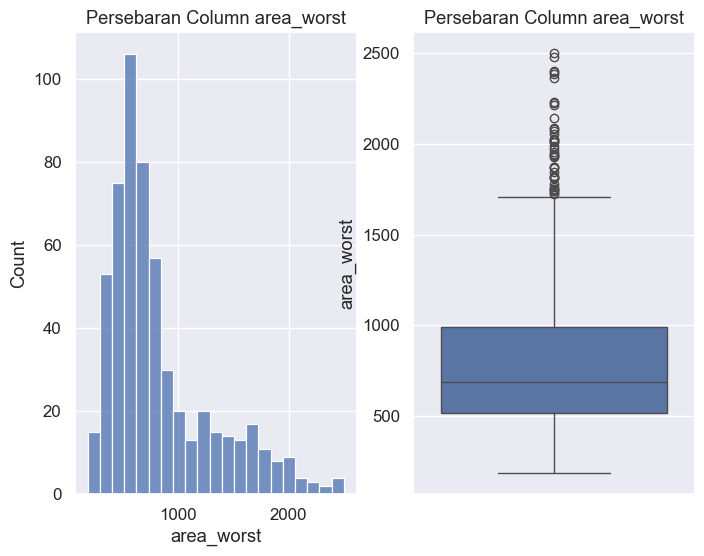

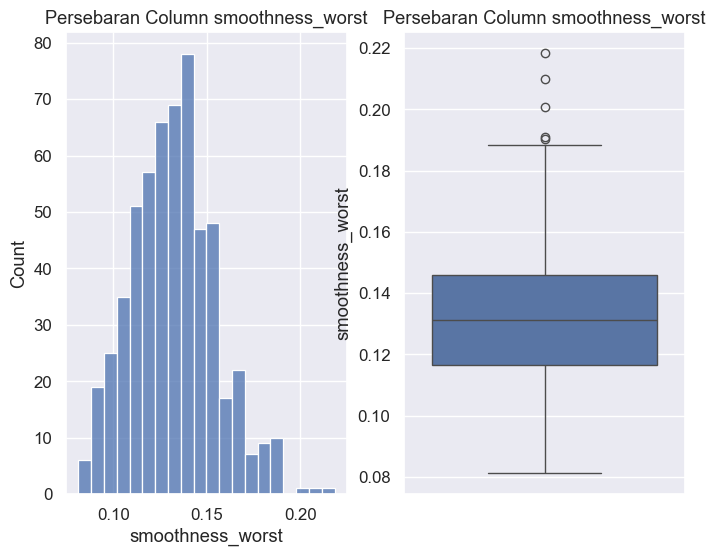

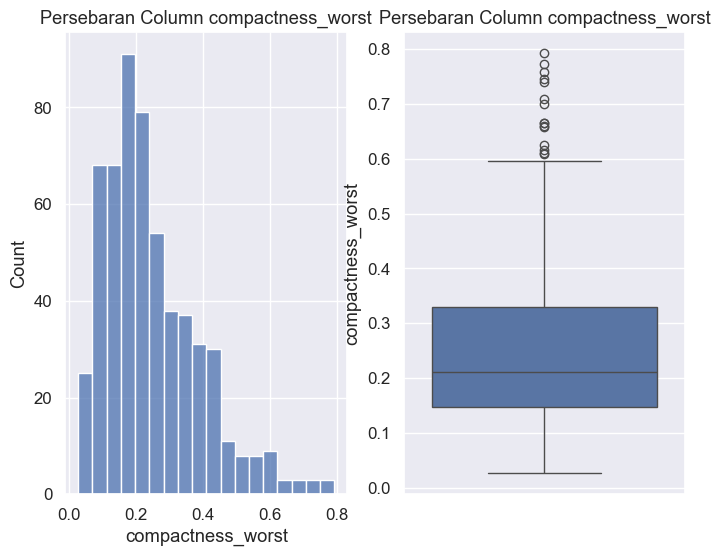

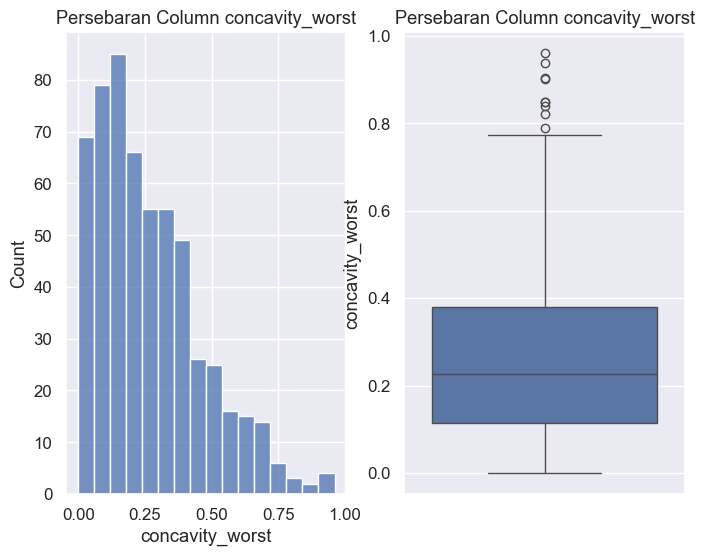

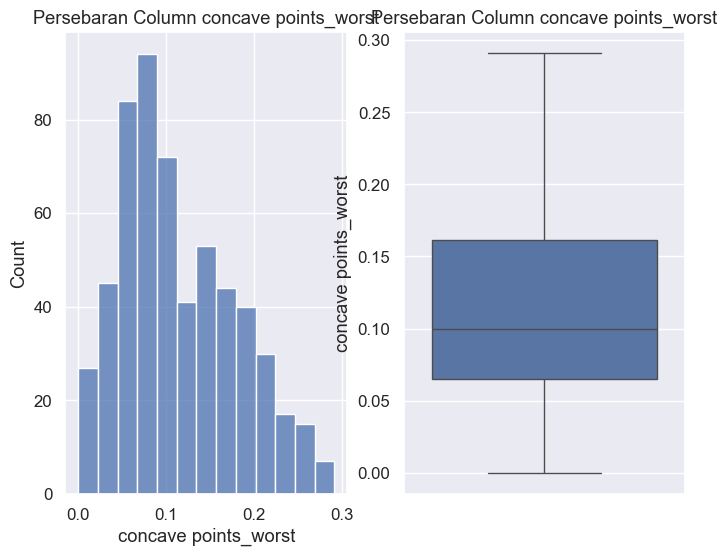

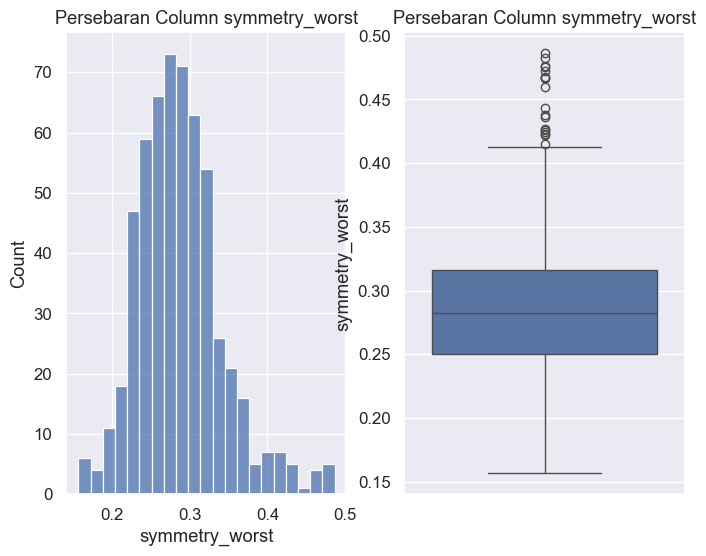

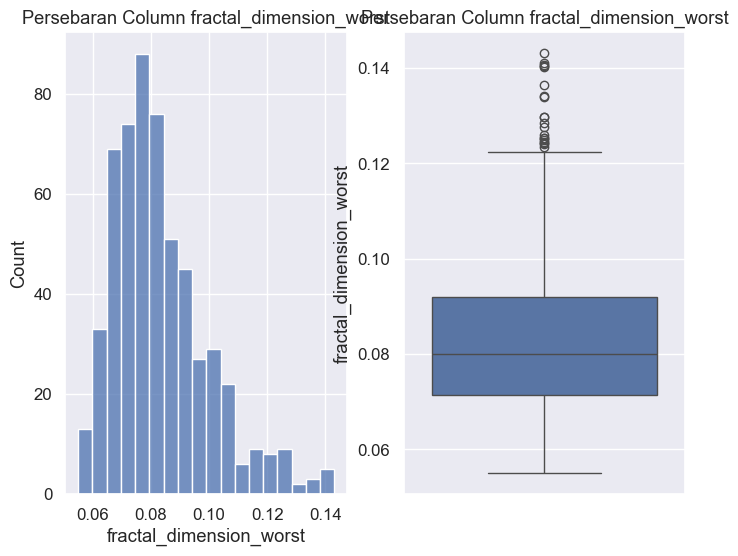

In [14]:
for col in df.select_dtypes(include='number'):
    fig, axes = plt.subplots(1, 2, figsize=(8,6))
    sns.histplot(df[col], ax=axes[0])
    axes[0].set_title(f"Persebaran Column {col}")
    sns.boxplot(df[col], ax=axes[1])
    axes[1].set_title(f"Persebaran Column {col}")
    
    plt.show()

In [15]:
df.skew()

id                         1.645013
diagnosis                  0.528461
radius_mean                0.796096
texture_mean               0.527067
perimeter_mean             0.842074
area_mean                  1.140465
smoothness_mean            0.356778
compactness_mean           1.059624
concavity_mean             1.248904
concave points_mean        1.171180
symmetry_mean              0.585830
fractal_dimension_mean     0.766993
radius_se                  1.393211
texture_se                 0.946876
perimeter_se               1.454993
area_se                    1.689637
smoothness_se              1.027220
compactness_se             1.221122
concavity_se               1.168735
concave points_se          0.650380
symmetry_se                1.079489
fractal_dimension_se       1.230983
radius_worst               1.050509
texture_worst              0.498321
perimeter_worst            1.031617
area_worst                 1.317756
smoothness_worst           0.369352
compactness_worst          1

## C. Exploratory Data Analysis (EDA)

### C.1 Visualisasi Label

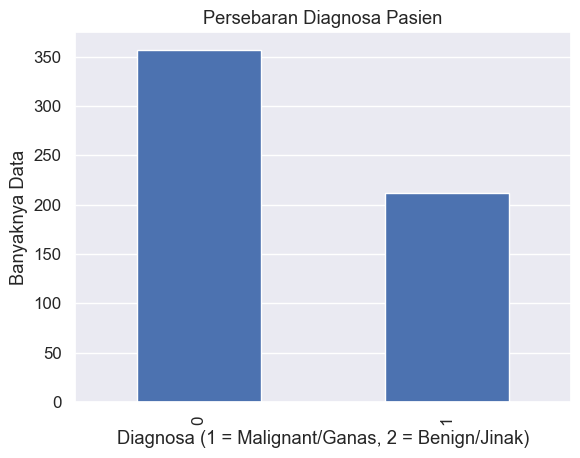

In [16]:
df['diagnosis'].value_counts().plot(kind='bar')
plt.xlabel("Diagnosa (1 = Malignant/Ganas, 2 = Benign/Jinak)")
plt.ylabel("Banyaknya Data")
plt.title("Persebaran Diagnosa Pasien")
plt.grid(axis='x')
plt.show()

### C.4 Visualisasi Concave ()

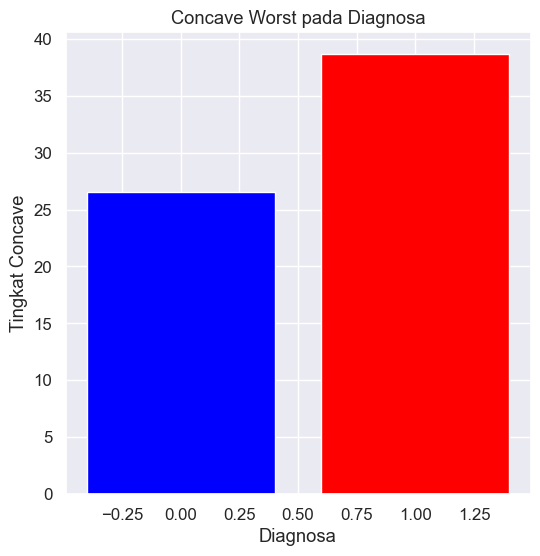

In [17]:
diagnosis_concave = df.groupby('diagnosis')['concave points_worst'].sum()
warna_label = ['blue', 'red']

plt.figure(figsize=(6, 6))
plt.bar(diagnosis_concave.index, diagnosis_concave.values, color=warna_label)
plt.title('Concave Worst pada Diagnosa')
plt.ylabel("Tingkat Concave")
plt.xlabel("Diagnosa")
plt.show()

### C.3 Visualisasi Korelasi

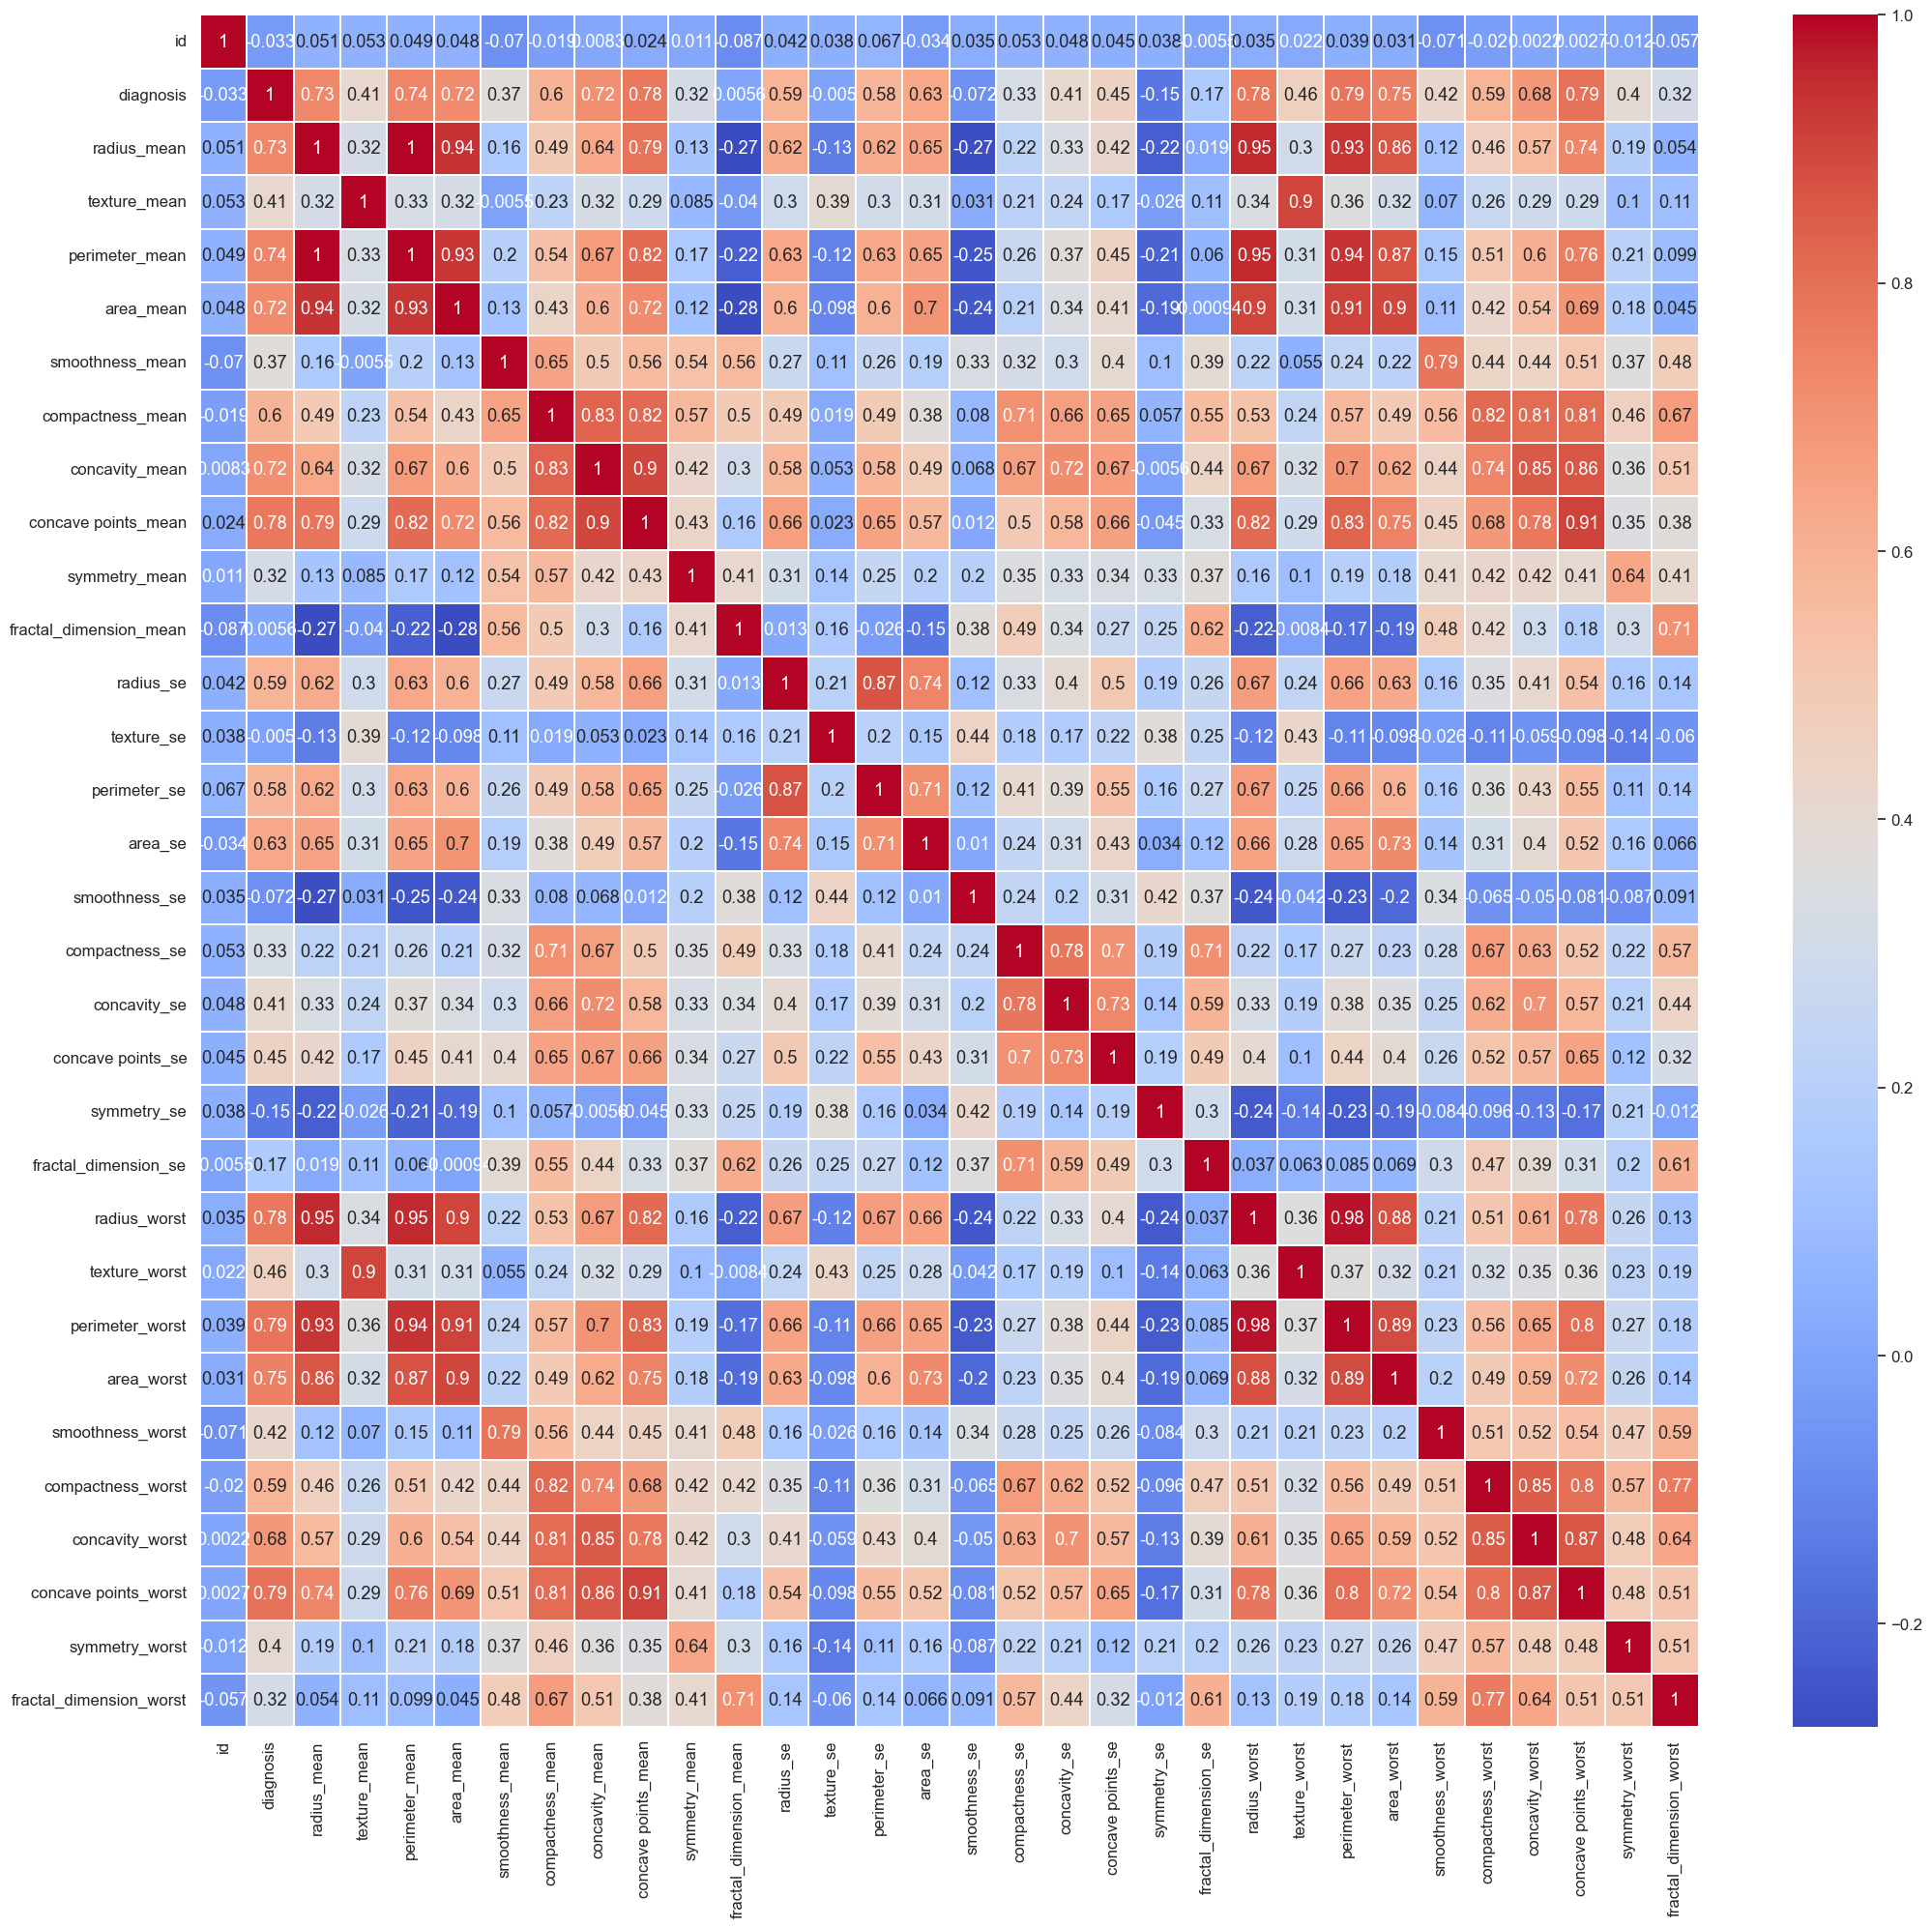

In [18]:
plt.figure(figsize=(25, 23))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=1.1)
plt.show()

### C.4 Feature Selection (Drop Unrelated Columns)

In [19]:
# df = df.drop(columns=['id', 'fractal_dimension_mean', 'symmetry_se', 'texture_se', 'smoothness_se', 'fractal_dimension_se'])
df = df.drop(columns=['id'])

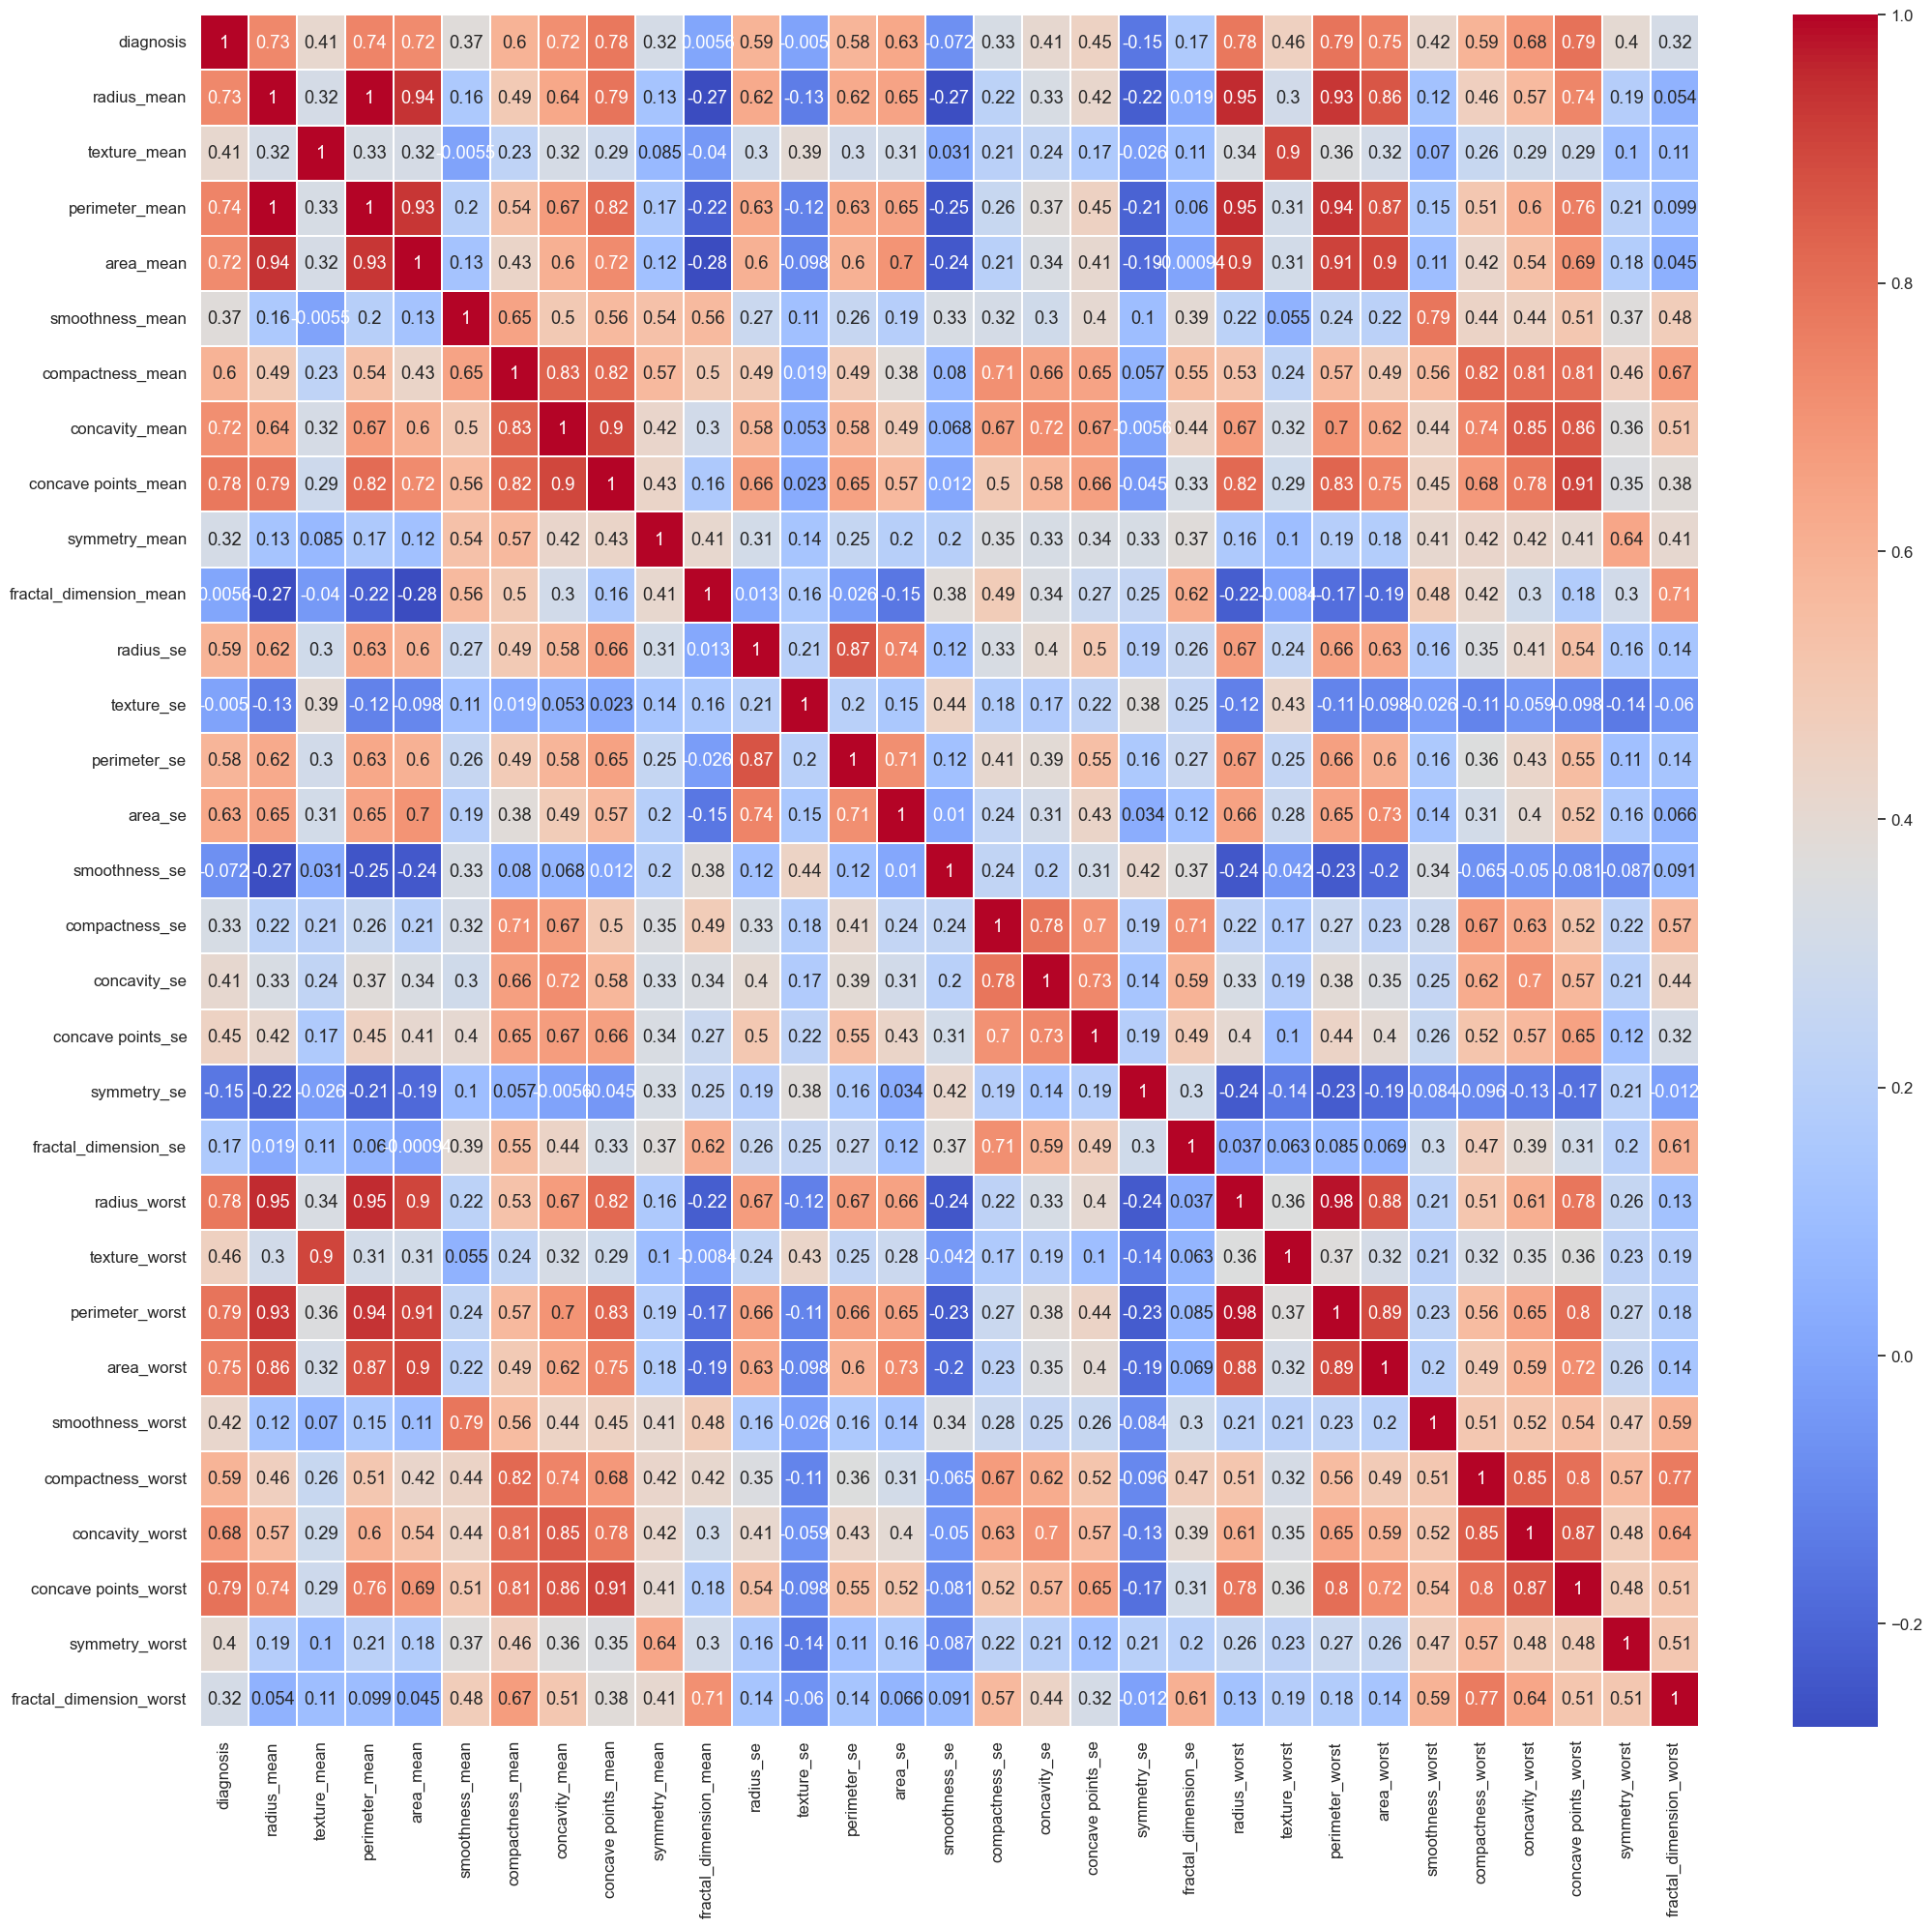

In [20]:
plt.figure(figsize=(25, 23))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=1.1)
plt.show()

## D. Modelling

### D.1 Normalize Features

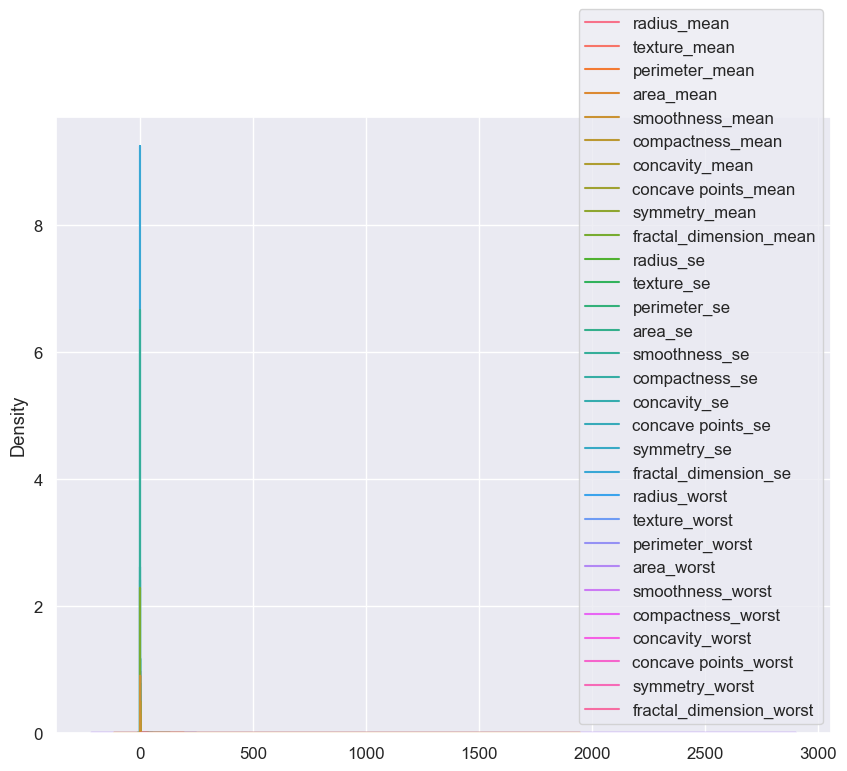

In [21]:
plt.figure(figsize=(10, 8))
sns.kdeplot(df.drop(columns='diagnosis'), legend=True)
plt.show()

In [22]:
# feature = df.drop(columns='diagnosis')
# target = df['diagnosis']

# feature_norm = (feature - feature.min()) / (feature.max() - feature.min())

# df = pd.concat([feature_norm, target], axis=1)

In [23]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.2119,0.6869,0.2575,0.2822,0.08004
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### D.2 Standardize Features

In [24]:
X = df.drop(columns='diagnosis')
y = df['diagnosis']

In [25]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std

X = standardize(X)

### D.3 Defining X (Feature) and y (Target) Variables

In [26]:
X_data = X
y_data = y

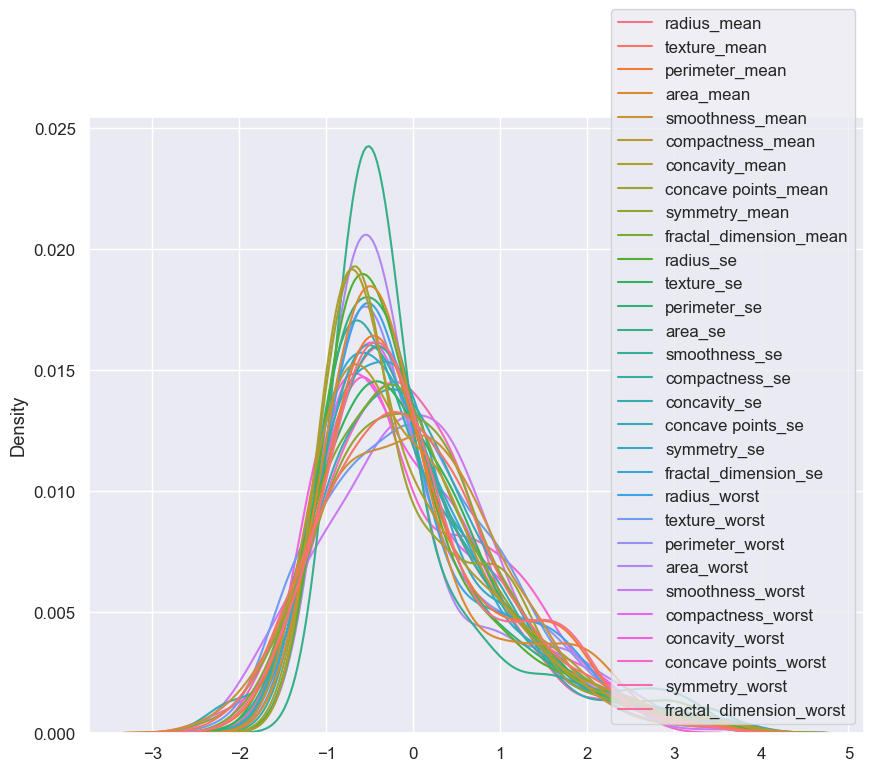

In [27]:
plt.figure(figsize=(10, 8))
sns.kdeplot(X_data, legend=True)
plt.show()

### D.4 Splitting Data Train dan Data Test (80:20)

In [28]:
# np.random.seed(42)
# indicies = np.random.permutation(len(X_data))

# test_size = int(len(X_data) * 0.8)

# train_idx = indicies[:test_size]
# test_idx = indicies[test_size:]

# X_train, X_test = X_data[train_idx], X_data[test_idx]
# y_train, y_test = y_data[train_idx], X_data[test_idx]

In [ ]:
# buat fungsi stratified split
def stratified_split(X_data, y_data, train_size=0.8, random_state=42, frac=None):
 # atur random menggunakan seed
 np.random.seed(random_state)

 if frac:
  X_data = X_data.sample(frac=frac, random_state=random_state)
  y_data = y_data.loc[X_data.index]

 X_train_list, X_test_list = [],[]
 y_train_list, y_test_list = [],[]

 for class_value in np.unique(y_data):
   class_idx = np.where(y_data==class_value)[0]

   idx = np.random.permutation(class_idx)
   split_ratio = int(len(idx)* train_size)

   X_train_list.append(X_data.iloc[idx[:split_ratio]])
   X_test_list.append(X_data.iloc[idx[split_ratio:]])
   y_train_list.append(y_data.iloc[idx[:split_ratio]])
   y_test_list.append(y_data.iloc[idx[split_ratio:]])

 X_train = pd.concat(X_train_list).reset_index(drop=True)
 X_test = pd.concat(X_test_list).reset_index(drop=True)
 y_train = pd.concat(y_train_list).reset_index(drop=True)
 y_test = pd.concat(y_test_list).reset_index(drop=True)

 return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = stratified_split(X_data, y_data)

In [30]:
print("Rasio Kanker di Data Asli:")
print(np.mean(y_data == 1)) 

print("\nRasio Kanker di Data Training (Hasil Stratified Split):")
print(np.mean(y_train == 1))

Rasio Kanker di Data Asli:
0.37258347978910367

Rasio Kanker di Data Training (Hasil Stratified Split):
0.3722466960352423


### D.5 Logistic Regression Formulas

#### Logit

In [31]:
def linear_equation(X, w, b):
    # X: Data fitur
    # w: Bobot (weights)
    # b: Bias
    z = np.dot(X, w) + b
    return z

#### Sigmoid

In [1]:
def sigmoid(z):
    # z: Hasil dari linear equation
    return 1 / (1 + np.exp(-z))

#### Loss Function

In [33]:
def log_loss(y_true, y_pred):
    # y_true: Kunci jawaban asli (0 atau 1)
    # y_pred: Prediksi probabilitas dari sigmoid
    
    epsilon = 1e-15
    # Jepit nilai biar gak 0 murni atau 1 murni
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

#### Gradient Descent


In [34]:
def grad_desc(X, y_true, y_pred):
    m = X.shape[0] # Jumlah data
    
    # Hitung selisih tebakan (Error term)
    error = y_pred - y_true
    
    # Turunan terhadap bobot (w)
    dw = (1 / m) * np.dot(X.T, error)
    
    # Turunan terhadap bias (b)
    db = (1 / m) * np.sum(error)
    
    return dw, db

#### Update Parameter

In [35]:
def update_parameters(w, b, dw, db, learning_rate):
    # learning_rate: Seberapa besar langkah kita (biasanya 0.01 atau 0.001)
    
    w_new = w - learning_rate * dw
    b_new = b - learning_rate * db
    
    return w_new, b_new

### D.6 Logistic Regression Training & Updating

In [36]:
# 1. Inisialisasi Parameter Awal (Semuanya nol)
# Kita butuh w sebanyak jumlah kolom fitur (X_train.shape[1])
w = np.zeros(X_train.shape[1])
b = 0
learning_rate = 0.01
epochs = 1000  # Jumlah putaran belajar
loss_history = []

# 2. Loop Belajar
print("Mulai Training:")
for i in range(epochs):
    # A. Maju (Forward Pass)
    z = linear_equation(X_train, w, b)       # Rumus 1
    y_pred = sigmoid(z)                      # Rumus 2
    
    # B. Hitung Error (Opsional, buat grafik)
    loss = log_loss(y_train, y_pred)     # Rumus 3
    loss_history.append(loss)
    
    # C. Mundur (Backward Pass - Cari arah perbaikan)
    dw, db = grad_desc(X_train, y_train, y_pred) # Rumus 4
    
    # D. Update (Perbaiki bobot)
    w, b = update_parameters(w, b, dw, db, learning_rate) # Rumus 5
    
    # Print progress setiap 100 putaran
    if i % 100 == 0:
        print(f"Epoch {i}: Loss = {loss:.4f}")

print("Training Selesai")

Mulai Training:
Epoch 0: Loss = 0.6931
Epoch 100: Loss = 0.2432
Epoch 200: Loss = 0.1861
Epoch 300: Loss = 0.1600
Epoch 400: Loss = 0.1442
Epoch 500: Loss = 0.1332
Epoch 600: Loss = 0.1251
Epoch 700: Loss = 0.1187
Epoch 800: Loss = 0.1136
Epoch 900: Loss = 0.1093
Training Selesai


### D.7 Logistic Regression Prediction

In [37]:
def predict(X, w, b, threshold=0.5):
    # 1. Hitung probabilitas (sama kayak waktu training)
    z = linear_equation(X, w, b)
    y_prob = sigmoid(z)
    
    # 2. Ubah probabilitas jadi kelas (0 atau 1)
    # List comprehension: Kalau p > 0.5 jadi 1, selain itu 0
    y_class = [1 if p > threshold else 0 for p in y_prob]
    
    return np.array(y_class)

## E. Evaluasi

### E.1 Akurasi

In [40]:
predictions = predict(X_test, w, b)
akurasi_test = np.sum(predictions == y_test) / len(X_test)
print(f"{akurasi_test:.2f}")

0.99


### E.2 Confusion Matrix

In [41]:
TP = np.sum((predictions == 1) & (y_test == 1))
FP = np.sum((predictions == 1) & (y_test == 0))
TN = np.sum((predictions == 0) & (y_test == 0))
FN = np.sum((predictions == 0) & (y_test == 1))

print(f"True Positives: {TP}")
print(f"False Positives: {FP}")
print(f"True Negatives: {TN}")
print(f"False Negatives: {FN}")

True Positives: 42
False Positives: 0
True Negatives: 72
False Negatives: 1


### E.3 Precision

In [ ]:
precision = TP / (TP + FP)
precision

np.float64(1.0)

### E.4 Recall

In [ ]:
recall = TP / (TP + FN)
recall

np.float64(0.9767441860465116)

### E.5 F-1 Score

In [ ]:
f1 = 2 * (precision * recall / precision + recall)
f1

np.float64(3.9069767441860463)

### E.6 Visualisasi Sigmoid

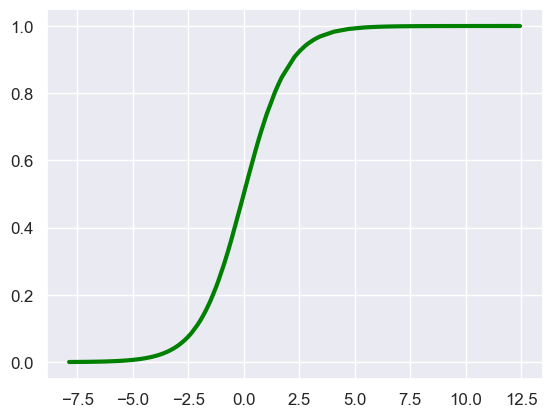

In [ ]:
z_test = np.dot(X_test, w) + b
z_sorted = np.sort(z_test)
sigmoid_sorted = sigmoid(z_sorted)

plt.plot(z_sorted, sigmoid_sorted, color='green', linewidth=3, label='Fungsi Sigmoid (Model)')

### E.7 Visualisasi Scatter Plot

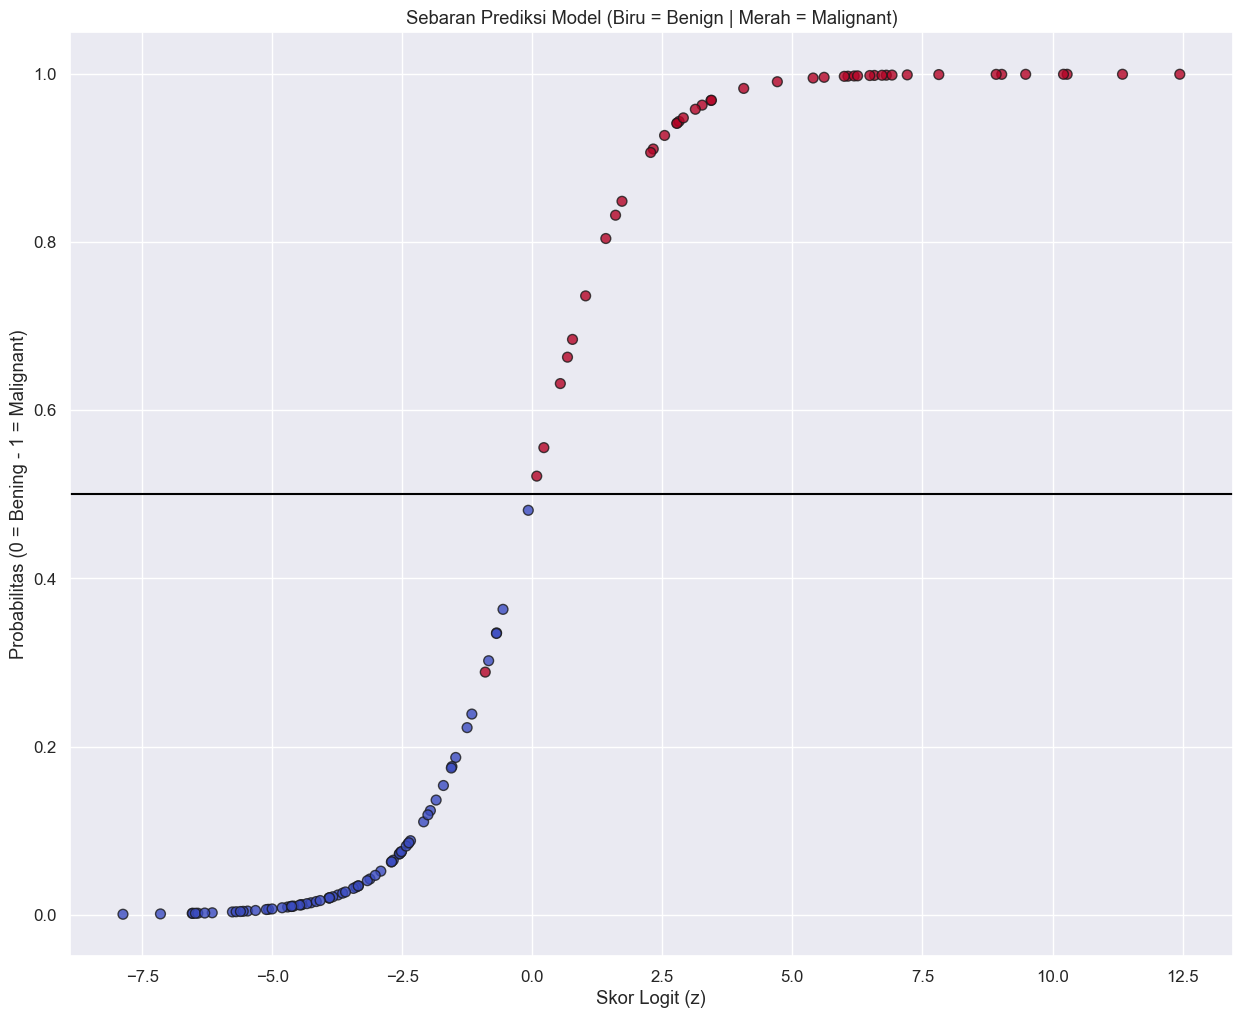

In [ ]:
z_test = np.dot(X_test, w) + b
probabilitas = sigmoid(z_test)

plt.figure(figsize=(15, 12))
plt.scatter(z_test, probabilitas, c=y_test, cmap='coolwarm', edgecolors='k', s=50, alpha=0.8)
plt.axhline(0.5, color='black', linestyle='-', label='Batas Keputusan/Threshold = 0.5')
plt.xlabel('Skor Logit (z)')
plt.ylabel('Probabilitas (0 = Bening - 1 = Malignant)')
plt.title('Sebaran Prediksi Model (Biru = Benign | Merah = Malignant)')
plt.grid(True)
plt.show()

Sedang mencari garis pemisah...


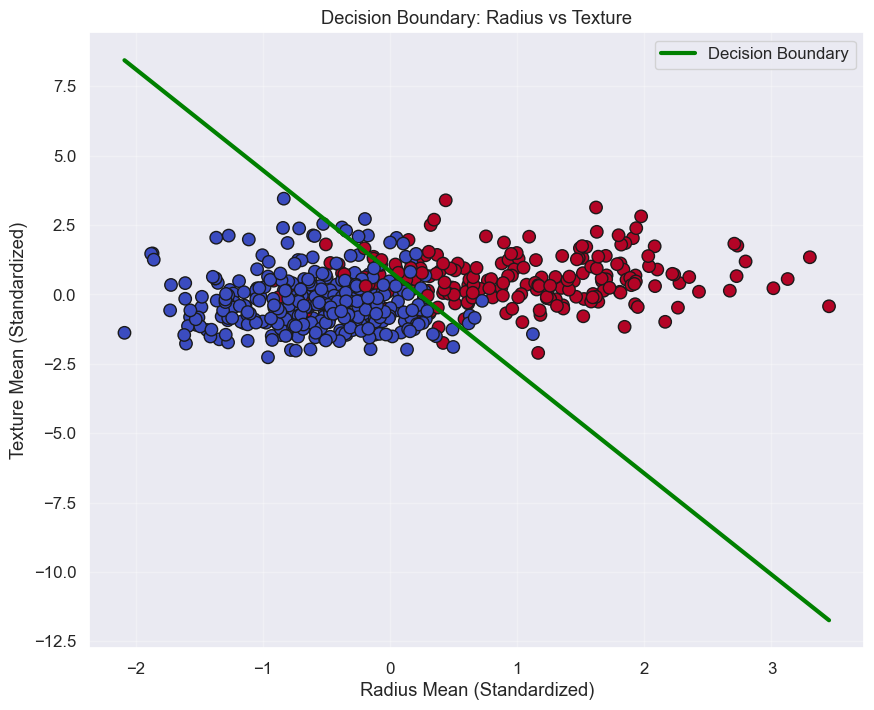

In [ ]:
# --- 1. PERSIAPAN DATA (Cuma Ambil 2 Fitur) ---
# Kita pakai 'radius_mean' (X) dan 'texture_mean' (Y) biar gampang dibayangkan
# Pastikan nama kolom sesuai dengan dataframe kamu
X_2fitur = df[['radius_mean', 'texture_mean']].values
y_2fitur = df['diagnosis'].values

# Standardisasi (WAJIB, kalau gak garisnya ilang)
mean_X = np.mean(X_2fitur, axis=0)
std_X = np.std(X_2fitur, axis=0)
X_norm = (X_2fitur - mean_X) / std_X

# --- 2. TRAINING ULANG (Khusus 2 Fitur ini aja) ---
# Kita butuh w baru (cuma 2 bobot) dan b baru
w_2d = np.zeros(2)
b_2d = 0
lr = 0.1
epochs = 1000

print("Sedang mencari garis pemisah...")
for i in range(epochs):
    # Rumus standar yang kamu pelajari tadi
    z = np.dot(X_norm, w_2d) + b_2d
    y_pred = 1 / (1 + np.exp(-z))
    
    dw = (1/len(X_norm)) * np.dot(X_norm.T, (y_pred - y_2fitur))
    db = (1/len(X_norm)) * np.sum(y_pred - y_2fitur)
    
    w_2d -= lr * dw
    b_2d -= lr * db

# --- 3. GAMBAR GARIS BATAS (The Magic Moment) ---
plt.figure(figsize=(10, 8))

# A. Scatter Plot Data Asli
plt.scatter(X_norm[:, 0], X_norm[:, 1], c=y_2fitur, cmap='coolwarm', edgecolors='k', s=80)

# B. Hitung Garis Decision Boundary
# Kita ambil titik paling kiri dan paling kanan dari data untuk ujung garisnya
x_values = np.array([np.min(X_norm[:, 0]), np.max(X_norm[:, 0])])

# RUMUS SAKTI: y = -(w1*x + b) / w2
y_values = -(w_2d[0] * x_values + b_2d) / w_2d[1]

# C. Plot Garisnya
plt.plot(x_values, y_values, label='Decision Boundary', color='green', linewidth=3)

# Hiasan
plt.title('Decision Boundary: Radius vs Texture')
plt.xlabel('Radius Mean (Standardized)')
plt.ylabel('Texture Mean (Standardized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Kesimpulan:

1. Logistic Regression Harus di Standarisasi
2. Logistic Regression lebih baik menggunakan Stratified Split daripada Random Split
3. Logistic Regression butuh fitur meski korelasi sedikit (Kecuali fitur yang tidak berkorelasi sama sekali)